In [1]:
# Core dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
sns.set_theme(style="whitegrid")


DATA_DIR = Path("data")
YEARS = [2024, 2025, 2026]

def read_hdx_csv(path, usecols=None):
 """Read Humanitarian Data eXchange exported CSVs (skip schema row, handle BOM)."""
 return pd.read_csv(path, skiprows=[1], encoding="utf-8-sig", usecols=usecols, low_memory=False)

def split_pipe_list(x):
 """Split pipe-separated strings into lists."""
 if pd.isna(x):
    return []
 return [p.strip() for p in str(x).split("|") if p.strip()]

def format_num(n):
 """Format large numbers for readability."""
 if n >= 1e9: 
   return f"{n/1e9:.1f}B"
 if n >= 1e6: 
   return f"{n/1e6:.1f}M"
 if n >= 1e3: 
   return f"{n/1e3:.0f}K"
 return str(int(n))

## 1. Data Loading

**Data Sources Used:**
- **HPC HNO (2024-2026)** — Humanitarian needs data: Population, In Need, Targeted by country/cluster
- **Humanitarian Response Plans** — Funding requirements per country/year
- **INFORM Severity Index (2020-2025)** — Crisis severity, drivers, and trends
- **COD Population Statistics** — Country population baselines

**Why these datasets?** They provide the complete picture of need (HNO) vs resources (HRP) while INFORM adds context on WHY crises occur and their severity.

In [2]:
# Load HNO data (humanitarian needs by country/year)
HNO_COLS = ["Country ISO3", "Description", "Cluster", "Category", "Population", "In Need", "Targeted"]

hno = pd.concat([
 read_hdx_csv(DATA_DIR / f"hpc_hno_{y}.csv", usecols=HNO_COLS).assign(year=y)
 for y in YEARS
], ignore_index=True)

# Convert numeric columns
for c in ["Population", "In Need", "Targeted"]:
 hno[c] = pd.to_numeric(hno[c], errors="coerce")

# Data summary
hno_summary = pd.DataFrame({
 "Metric": ["Total Records", "Years Covered", "Countries"],
 "Value": [f"{len(hno):,}", f"{sorted(hno['year'].unique())}", hno['Country ISO3'].nunique()]
})

display(hno_summary.style.hide(axis="index"))

Metric,Value
Total Records,"706,211"
Years Covered,"[np.int64(2024), np.int64(2025), np.int64(2026)]"
Countries,24


In [3]:
hno.head()

,Country ISO3,Description,Cluster,Category,Population,In Need,Targeted,year
0,AFG,Final HNRP Caseload,ALL,NaN,44532600.0,23666389.0,17327995.0,2024
1,AFG,Final HNRP Caseload,ALL,Adult,NaN,10876422.0,7982696.0,2024
2,AFG,Final HNRP Caseload,ALL,Adult - Female,NaN,5857561.0,4090179.0,2024
3,AFG,Final HNRP Caseload,ALL,Adult - Female - Border / EC,NaN,184946.0,164215.0,2024
4,AFG,Final HNRP Caseload,ALL,Adult - Female - IDP,NaN,34726.0,26347.0,2024


In [4]:
# Load HRP data (humanitarian response plans - funding requirements)
HRP_COLS = ["code", "startDate", "endDate", "locations", "years", "origRequirements", "revisedRequirements"]
hrp = read_hdx_csv(DATA_DIR / "humanitarian-response-plans.csv", usecols=HRP_COLS)

for c in ["origRequirements", "revisedRequirements"]:
 hrp[c] = pd.to_numeric(hrp[c], errors="coerce")

hrp["startDate"] = pd.to_datetime(hrp["startDate"], errors="coerce")
hrp["endDate"] = pd.to_datetime(hrp["endDate"], errors="coerce")
hrp["loc_list"] = hrp["locations"].apply(split_pipe_list)
hrp["year_list"] = hrp["years"].apply(split_pipe_list)
hrp["n_locations"] = hrp["loc_list"].map(len)

# Data summary
hrp_summary = pd.DataFrame({
 "Metric": ["Total Plans", "Single-Country Plans", "Total Requirements (USD)"],
 "Value": [f"{len(hrp):,}", f"{(hrp['n_locations'] == 1).sum():,}", f"${hrp['revisedRequirements'].sum()/1e9:.1f}B"]
})
display(hrp_summary.style.hide(axis="index"))


Metric,Value
Total Plans,910
Single-Country Plans,811
Total Requirements (USD),$552.0B


In [5]:
hrp.head()

,code,startDate,endDate,locations,years,origRequirements,revisedRequirements,loc_list,year_list,n_locations
0,HHTI26,2026-01-01,2026-12-31,HTI,2026,880327426,880327426,[HTI],[2026],1
1,RREG26,2026-01-01,2026-12-31,YEM | KEN | DJI | SOM | ETH | TZA,2026,0,52990581,"[YEM, KEN, DJI, SOM, ETH, TZA]",[2026],6
2,FPSE26,2026-01-01,2026-12-31,PSE,2026,4064305808,4064305808,[PSE],[2026],1
3,HMLI26,2026-01-01,2026-12-31,MLI,2026,0,551000000,[MLI],[2026],1
4,OPAK26,2026-01-01,2026-04-30,PAK,2026,0,64943909,[PAK],[2026],1


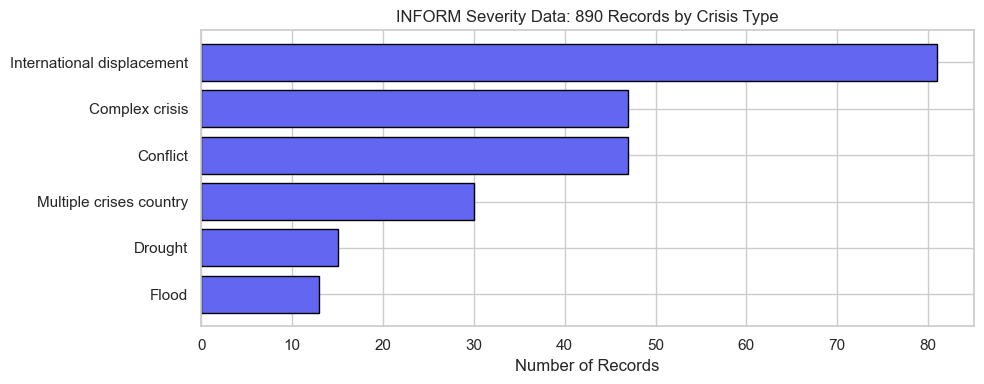

In [6]:
# Load INFORM Severity Index (enriches analysis with crisis context)
inform_path = DATA_DIR / "inform_severity_master_2020_2025.csv"
inform_raw = pd.read_csv(inform_path, encoding="utf-8-sig", low_memory=False)

# Skip metadata rows
inform = inform_raw.iloc[2:].copy()

# Select and rename key columns
inform_cols = {
 "COUNTRY": "country_name",
 "ISO3": "iso3",
 "TYPE OF CRISIS": "crisis_type",
 "INFORM Severity Index": "severity_index",
 "INFORM Severity category.1": "severity_category",
 "Trend (last 3 months)": "trend",
 "Regions": "region",
 "Year": "year",
 "DRIVERS": "drivers",
 "Complexity of the crisis": "complexity",
 "Operating environment": "operating_env",
}

inform = inform[list(inform_cols.keys())].rename(columns=inform_cols)

for col in ["severity_index", "year", "complexity", "operating_env"]:
 inform[col] = pd.to_numeric(inform[col], errors="coerce")

def get_primary_driver(x):
 if pd.isna(x) or str(x).strip() == "":
    return "Unknown"
 return str(x).split(",")[0].strip()

inform["primary_driver"] = inform["drivers"].apply(get_primary_driver)
inform = inform[~inform["iso3"].str.contains(",", na=False)].copy()

# Keep a stable copy for later joins (other sections may reuse the name `inform`)
inform_master = inform.copy()

# Display crisis type distribution
fig, ax = plt.subplots(figsize=(10, 4))
crisis_counts = inform["crisis_type"].value_counts().head(6)
ax.barh(crisis_counts.index, crisis_counts.values, color="#6366f1", edgecolor="black")
ax.set_xlabel("Number of Records")
ax.set_title(f"INFORM Severity Data: {len(inform):,} Records by Crisis Type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [7]:
#INFORM severity index
inform.head()

,country_name,iso3,crisis_type,severity_index,severity_category,trend,region,year,drivers,complexity,operating_env,primary_driver
2,Afghanistan,AFG,Complex crisis,4.6,Very High,Increasing,Asia,2020,NaN,4.3,4.5,Unknown
3,Algeria,DZA,International displacement,NaN,x,-,Africa,2020,NaN,2.5,2.0,Unknown
4,Algeria,DZA,International displacement,2.3,Medium,Increasing,Africa,2020,NaN,2.3,1.5,Unknown
5,Algeria,DZA,Multiple crises country,NaN,x,-,Africa,2020,NaN,2.5,2.0,Unknown
8,Armenia,ARM,Conflict,NaN,x,-,Asia,2020,NaN,1.9,2.0,Unknown


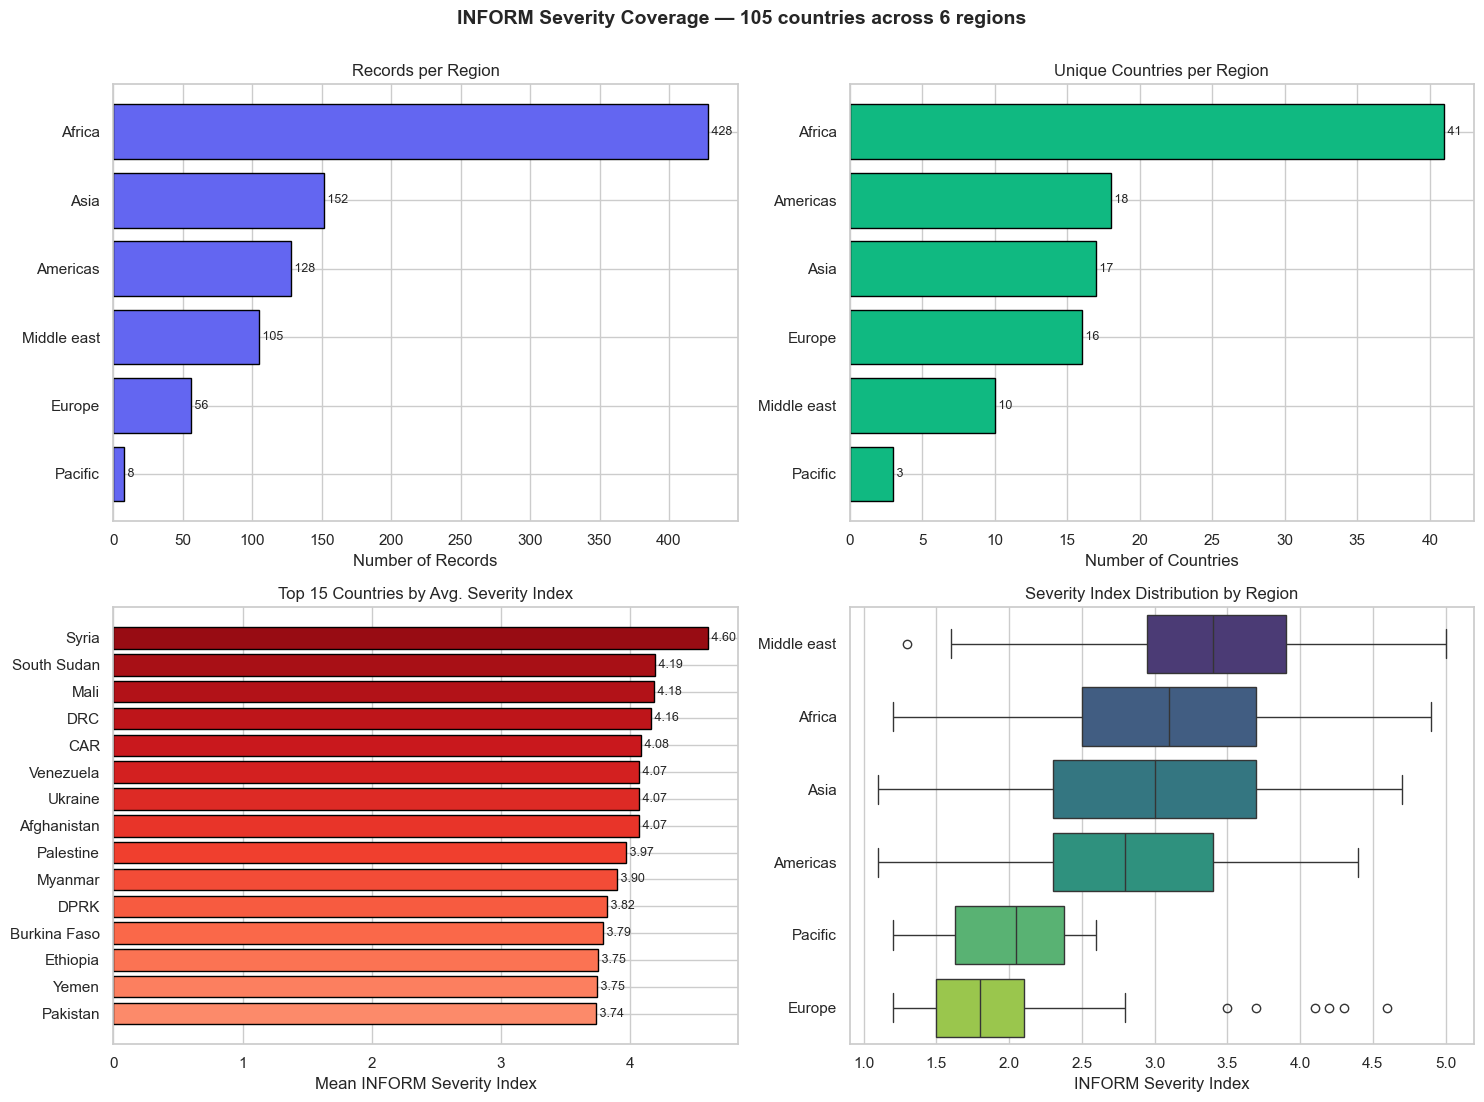


Coverage summary:
  Total countries: 105
  Total regions:   6
  Years covered:   [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


In [8]:
# Countries and Regions covered by INFORM Severity data
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# --- 1. Records per region ---
region_counts = (
    inform.dropna(subset=["region"])
          .groupby("region").size()
          .sort_values(ascending=True)
)
axes[0, 0].barh(region_counts.index, region_counts.values,
                color="#6366f1", edgecolor="black")
axes[0, 0].set_title("Records per Region")
axes[0, 0].set_xlabel("Number of Records")
for i, v in enumerate(region_counts.values):
    axes[0, 0].text(v, i, f" {v:,}", va="center", fontsize=9)

# --- 2. Unique countries per region ---
countries_per_region = (
    inform.dropna(subset=["region", "iso3"])
          .groupby("region")["iso3"].nunique()
          .sort_values(ascending=True)
)
axes[0, 1].barh(countries_per_region.index, countries_per_region.values,
                color="#10b981", edgecolor="black")
axes[0, 1].set_title("Unique Countries per Region")
axes[0, 1].set_xlabel("Number of Countries")
for i, v in enumerate(countries_per_region.values):
    axes[0, 1].text(v, i, f" {v}", va="center", fontsize=9)

# --- 3. Top 15 countries by average severity index ---
top_countries = (
    inform.dropna(subset=["severity_index", "country_name"])
          .groupby("country_name")["severity_index"].mean()
          .sort_values(ascending=False)
          .head(15)
          .sort_values(ascending=True)  # ascending for horizontal bar
)
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_countries)))
axes[1, 0].barh(top_countries.index, top_countries.values,
                color=colors, edgecolor="black")
axes[1, 0].set_title("Top 15 Countries by Avg. Severity Index")
axes[1, 0].set_xlabel("Mean INFORM Severity Index")
for i, v in enumerate(top_countries.values):
    axes[1, 0].text(v, i, f" {v:.2f}", va="center", fontsize=9)

# --- 4. Severity index distribution by region ---
region_order = (
    inform.dropna(subset=["region", "severity_index"])
          .groupby("region")["severity_index"].median()
          .sort_values(ascending=False).index
)
sns.boxplot(
    data=inform.dropna(subset=["region", "severity_index"]),
    y="region", x="severity_index",
    order=region_order,
    ax=axes[1, 1], palette="viridis"
)
axes[1, 1].set_title("Severity Index Distribution by Region")
axes[1, 1].set_xlabel("INFORM Severity Index")
axes[1, 1].set_ylabel("")

plt.suptitle(
    f"INFORM Severity Coverage — {inform['iso3'].nunique()} countries across {inform['region'].nunique()} regions",
    fontsize=14, fontweight="bold", y=1.00
)
plt.tight_layout()
plt.show()

# Print concise summary
print(f"\nCoverage summary:")
print(f"  Total countries: {inform['iso3'].nunique()}")
print(f"  Total regions:   {inform['region'].nunique()}")
print(f"  Years covered:   {sorted(inform['year'].dropna().astype(int).unique())}")

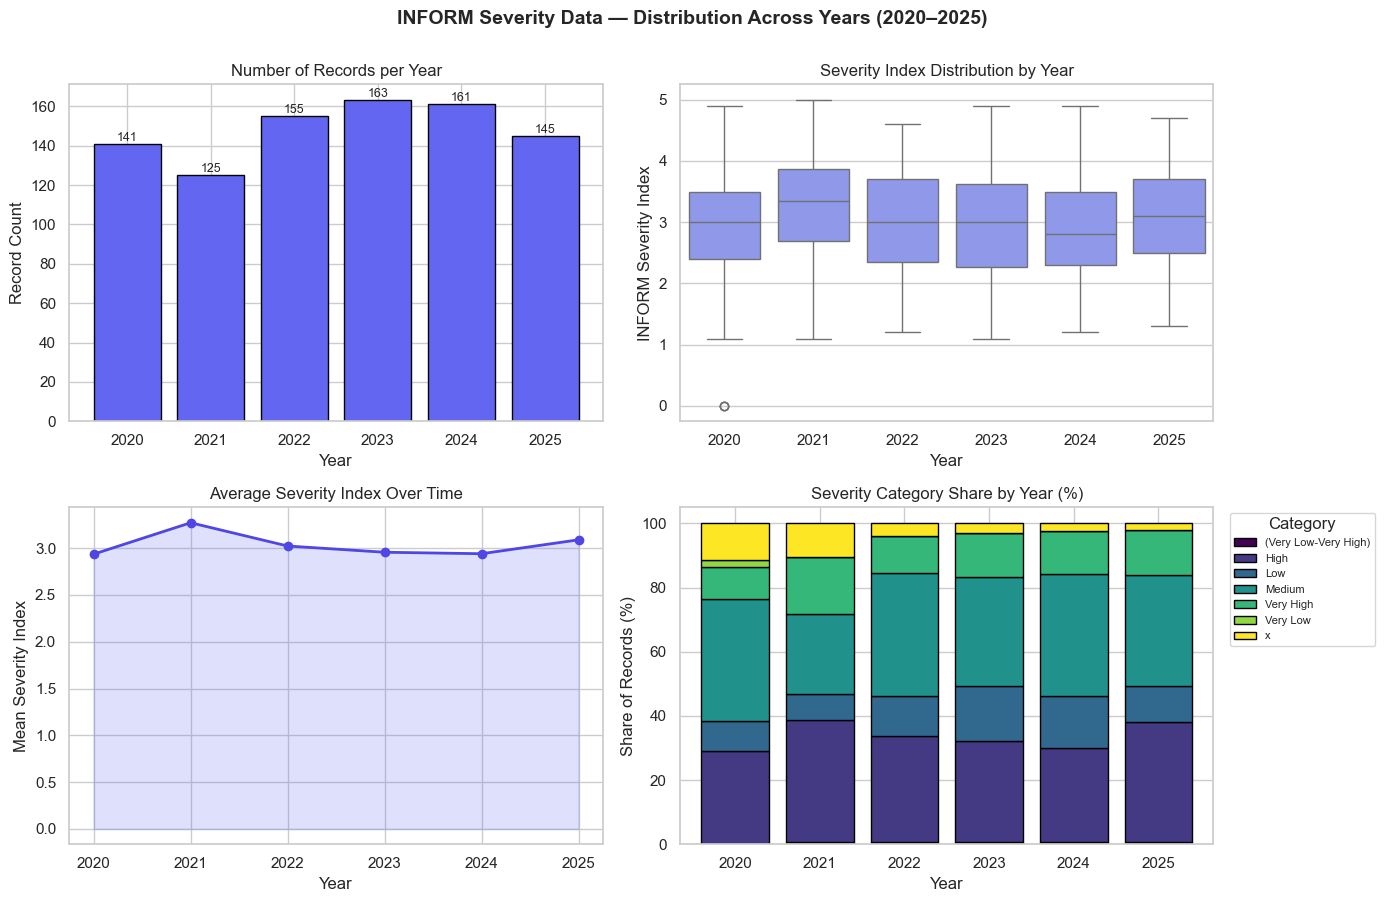

In [9]:
# Distribution of INFORM Severity data across years
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# --- 1. Record counts per year ---
year_counts = inform["year"].value_counts().sort_index()
axes[0, 0].bar(year_counts.index.astype(int), year_counts.values,
               color="#6366f1", edgecolor="black")
axes[0, 0].set_title("Number of Records per Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Record Count")
for x, y in zip(year_counts.index.astype(int), year_counts.values):
    axes[0, 0].text(x, y, f"{y:,}", ha="center", va="bottom", fontsize=9)

# --- 2. Severity index distribution by year (boxplot) ---
sns.boxplot(
    data=inform.dropna(subset=["severity_index", "year"]),
    x="year", y="severity_index",
    ax=axes[0, 1], color="#818cf8"
)
axes[0, 1].set_title("Severity Index Distribution by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("INFORM Severity Index")

# --- 3. Mean severity index trend ---
mean_sev = inform.groupby("year")["severity_index"].mean().sort_index()
axes[1, 0].plot(mean_sev.index.astype(int), mean_sev.values,
                marker="o", color="#4f46e5", linewidth=2)
axes[1, 0].fill_between(mean_sev.index.astype(int), mean_sev.values,
                        alpha=0.2, color="#6366f1")
axes[1, 0].set_title("Average Severity Index Over Time")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Mean Severity Index")

# --- 4. Severity category composition by year (stacked %) ---
cat_by_year = (
    inform.dropna(subset=["severity_category", "year"])
          .groupby(["year", "severity_category"]).size()
          .unstack(fill_value=0)
)
cat_pct = cat_by_year.div(cat_by_year.sum(axis=1), axis=0) * 100
cat_pct.plot(kind="bar", stacked=True, ax=axes[1, 1],
             colormap="viridis", edgecolor="black", width=0.8)
axes[1, 1].set_title("Severity Category Share by Year (%)")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Share of Records (%)")
axes[1, 1].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
axes[1, 1].tick_params(axis="x", rotation=0)

plt.suptitle("INFORM Severity Data — Distribution Across Years (2020–2025)",
             fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

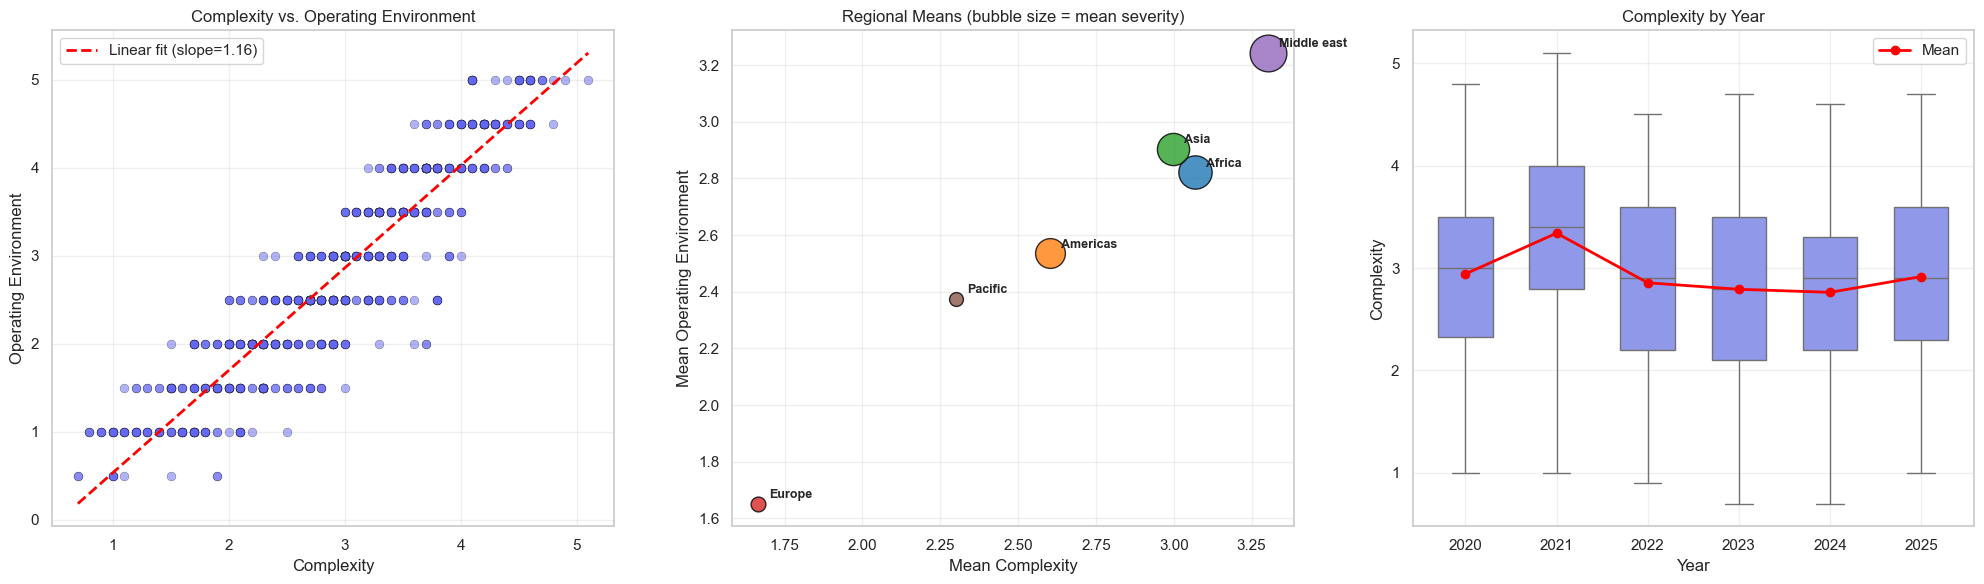

In [10]:
plot_df = inform.dropna(subset=["complexity", "operating_env", "region"]).copy()
plot_df["severity_index"] = pd.to_numeric(plot_df["severity_index"], errors="coerce")
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce")

regions = sorted(plot_df["region"].unique())
palette = dict(zip(regions, sns.color_palette("tab10", n_colors=len(regions))))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: scatter of complexity vs operating environment ---
axes[0].scatter(
    plot_df["complexity"], plot_df["operating_env"],
    s=40, alpha=0.5, color="#6366f1",
    edgecolor="black", linewidth=0.3
)
axes[0].set_title("Complexity vs. Operating Environment")
axes[0].set_xlabel("Complexity")
axes[0].set_ylabel("Operating Environment")
axes[0].grid(True, alpha=0.3)

if plot_df[["complexity", "operating_env"]].dropna().shape[0] > 1:
    z = np.polyfit(plot_df["complexity"], plot_df["operating_env"], 1)
    xs = np.linspace(plot_df["complexity"].min(), plot_df["complexity"].max(), 100)
    axes[0].plot(xs, np.polyval(z, xs), color="red", linewidth=2,
                 linestyle="--", label=f"Linear fit (slope={z[0]:.2f})")
    axes[0].legend()

# --- Plot 2: regional means, bubble size = mean severity ---
agg = (
    plot_df.groupby("region")
           .agg(complexity=("complexity", "mean"),
                operating_env=("operating_env", "mean"),
                severity=("severity_index", "mean"),
                n=("iso3", "count"))
           .reset_index()
)

sev = agg["severity"].fillna(agg["severity"].mean())
sizes = 100 + (sev - sev.min()) / max(sev.max() - sev.min(), 1e-9) * 600

for i, row in agg.iterrows():
    axes[1].scatter(
        row["complexity"], row["operating_env"],
        s=sizes.iloc[i], color=palette[row["region"]],
        alpha=0.8, edgecolor="black", linewidth=1
    )
    axes[1].annotate(
        row["region"],
        (row["complexity"], row["operating_env"]),
        xytext=(8, 4), textcoords="offset points",
        fontsize=9, fontweight="bold"
    )

axes[1].set_title("Regional Means (bubble size = mean severity)")
axes[1].set_xlabel("Mean Complexity")
axes[1].set_ylabel("Mean Operating Environment")
axes[1].grid(True, alpha=0.3)

# --- Plot 3: complexity over years ---
year_df = plot_df.dropna(subset=["year", "complexity"]).copy()
year_df["year"] = year_df["year"].astype(int)

sns.boxplot(
    data=year_df, x="year", y="complexity",
    ax=axes[2], color="#818cf8", width=0.6
)

# Overlay mean trend line
mean_by_year = year_df.groupby("year")["complexity"].mean().sort_index()
years_sorted = mean_by_year.index.tolist()
x_positions = range(len(years_sorted))
axes[2].plot(x_positions, mean_by_year.values,
             color="red", marker="o", linewidth=2,
             label="Mean", zorder=5)

axes[2].set_title("Complexity by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Complexity")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Data Preprocessing & Feature Engineering

Key preprocessing steps:
1) Extract "overall caseload" rows from HNO (Cluster='ALL', Category blank) for country-level totals
2) Filter HRP to single-country plans to avoid mis-attributing regional budgets
3) Join INFORM severity data to add crisis context
4) Engineer derived metrics: need_rate, coverage_rate, usd_per_person_in_need, share_gap, mismatch scores

**Handling Missing Values:**
- Population/In Need/Targeted: Drop rows with missing critical values (< 1% of data)
- revisedRequirements: Use 0 when missing (conservative — assumes no funding requested)
- INFORM severity: Use 2025 data for 2026 (most recent available)

**Key Column Selection:**
- `In Need` — Primary measure of humanitarian need
- `Population` — Denominator for need_rate calculation
- `revisedRequirements` — Best proxy for resource allocation (requested funding)
- `severity_index` — External validation of crisis severity

In [11]:
#This cell shows the different types of values the cluster datapoint can take. Cluster specifies where the money is allocated.

# IASC humanitarian cluster code → full name mapping
CLUSTER_NAMES = {
    # Aggregate
    "ALL": "All Sectors",

    # Core technical clusters
    "WSH":  "Water, Sanitation and Hygiene",   # (WASH)
    "WASH": "Water, Sanitation and Hygiene",
    "NUT":  "Nutrition",
    "HEA":  "Health",
    "HEALTH": "Health",
    "EDU":  "Education",
    "FSC":  "Food Security",
    "FSL":  "Food Security and Livelihoods",
    "FS":   "Food Security",
    "AGR":  "Agriculture",                      # sometimes split from FSC

    # Shelter-related
    "SHL":     "Shelter",
    "SHELTER": "Shelter",
    "NFI":     "Non-Food Items",
    "S-NFI":   "Shelter and Non-Food Items",
    "SNFI":    "Shelter and Non-Food Items",
    "CCM":     "Camp Coordination and Camp Management",   # (CCCM)
    "CCCM":    "Camp Coordination and Camp Management",
    "SLSC":    "Shelter, Land and Site Coordination",

    # Protection cluster and its Areas of Responsibility (AoRs)
    "PRO":        "Protection",
    "PROT":       "Protection",
    "PROTECTION": "Protection",
    "PRO-GBV":    "Protection — Gender-Based Violence",
    "GBV":        "Gender-Based Violence",
    "PRO-CPN":    "Protection — Child Protection",
    "PRO-CP":     "Protection — Child Protection",
    "CP":         "Child Protection",
    "PRO-MIN":    "Protection — Mine Action",
    "MA":         "Mine Action",
    "PRO-HLP":    "Protection — Housing, Land and Property",
    "HLP":        "Housing, Land and Property",

    # Service clusters
    "LOG": "Logistics",
    "ETC": "Emergency Telecommunications",
    "TEL": "Emergency Telecommunications",   # (ETC)

    # Cross-cutting / other
    "ERY":   "Early Recovery",                 # (ER)
    "ER":    "Early Recovery",
    "EREC":  "Early Recovery",
    "MPC":   "Multi-Purpose Cash Assistance",  # (MPCA)
    "MPCA":  "Multi-Purpose Cash Assistance",
    "CVA":   "Cash and Voucher Assistance",
    "MS":    "Multi-Sector",                   # common in refugee contexts
    "CSS":   "Coordination and Support Services",
    "COORD": "Coordination",
    "RMS":   "Refugee and Migrant Support",
}

def cluster_full_name(code):
    """Return full cluster name, falling back to the code itself if unknown."""
    if pd.isna(code):
        return "Unknown"
    key = str(code).strip().upper()
    return CLUSTER_NAMES.get(key, str(code))

# --- Apply to the data ---
hno["cluster_name"] = hno["Cluster"].apply(cluster_full_name)

# Nice summary: counts per cluster with full name
cluster_summary = (
    hno.groupby(["Cluster", "cluster_name"])
       .size()
       .reset_index(name="records")
       .sort_values("records", ascending=False)
)
print("Cluster codes in HNO data:")
print(cluster_summary.to_string(index=False))

# --- Flag any codes still unmapped ---
unmapped = sorted(
    c for c in hno["Cluster"].dropna().unique()
    if str(c).strip().upper() not in CLUSTER_NAMES
)
if unmapped:
    print(f"\n⚠️  {len(unmapped)} cluster code(s) not in dictionary:")
    for c in unmapped:
        print(f"  - {c!r}")
else:
    print("\n✅ All cluster codes mapped.")

Cluster codes in HNO data:
Cluster                            cluster_name  records
    PRO                              Protection   109875
    FSC                           Food Security    66254
    ALL                             All Sectors    63866
PRO-GBV      Protection — Gender-Based Violence    61751
    WSH           Water, Sanitation and Hygiene    57802
    HEA                                  Health    57438
PRO-CPN           Protection — Child Protection    56411
    SHL                                 Shelter    48747
    NUT                               Nutrition    44249
    EDU                               Education    33953
PRO-MIN                Protection — Mine Action    31966
PRO-HLP Protection — Housing, Land and Property    30502
    CCM   Camp Coordination and Camp Management    16297
    AGR                             Agriculture     7290
    MPC           Multi-Purpose Cash Assistance     5143
     MS                            Multi-Sector     3662
    

People in Need by Cluster (all years combined):

  Protection                                         In Need:   464.6M   Targeted:   164.1M
  Food Security                                      In Need:   394.9M   Targeted:   216.2M
  Health                                             In Need:   361.7M   Targeted:   176.6M
  Water, Sanitation and Hygiene                      In Need:   345.9M   Targeted:   169.3M
  Shelter                                            In Need:   199.5M   Targeted:    62.2M
  Protection — Gender-Based Violence                 In Need:   169.5M   Targeted:    45.1M
  Nutrition                                          In Need:   153.0M   Targeted:    93.6M
  Education                                          In Need:   152.0M   Targeted:    55.3M
  Protection — Child Protection                      In Need:   148.5M   Targeted:    55.3M
  Protection — Mine Action                           In Need:   115.7M   Targeted:    34.7M
  Camp Coordination and Camp Ma

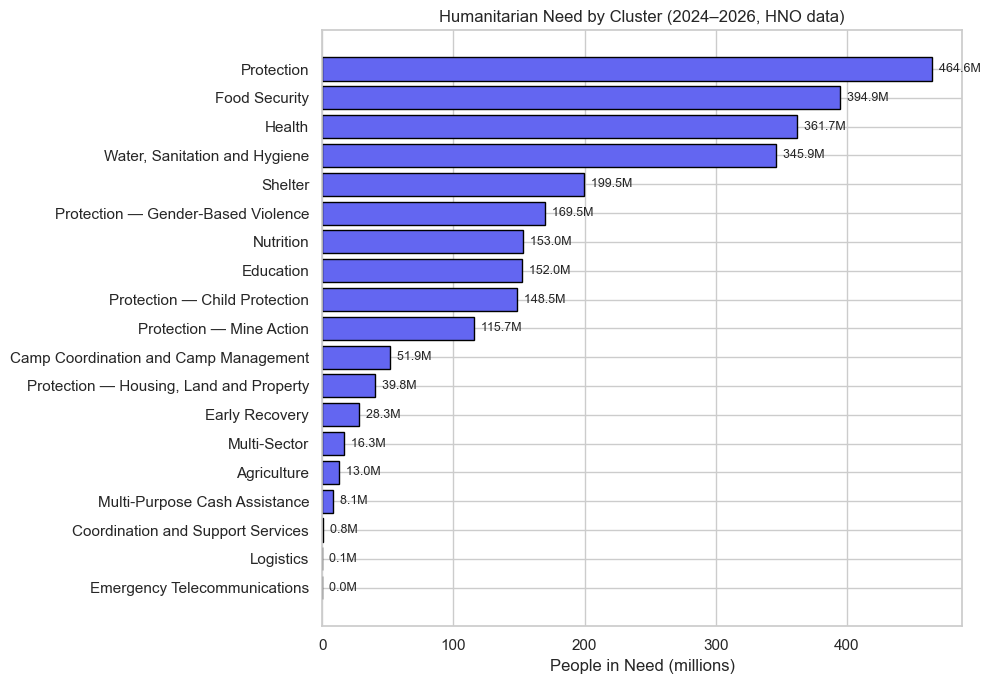

In [12]:
# People in Need by cluster (from HNO directly)
hno_by_cluster = (
    hno.query("Category == '' or Category != Category")  # top-level rows only
       .groupby(["Cluster", "cluster_name"], as_index=False)
       .agg(in_need=("In Need", "sum"),
            targeted=("Targeted", "sum"))
       .sort_values("in_need", ascending=False)
)

# Drop the "ALL" aggregate row so we don't double-count
hno_by_cluster = hno_by_cluster[hno_by_cluster["Cluster"] != "ALL"].reset_index(drop=True)

# Pretty print
print("People in Need by Cluster (all years combined):\n")
for _, r in hno_by_cluster.iterrows():
    print(f"  {r['cluster_name']:<50} In Need: {format_num(r['in_need']):>8}   Targeted: {format_num(r['targeted']):>8}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(hno_by_cluster["cluster_name"], hno_by_cluster["in_need"] / 1e6,
        color="#6366f1", edgecolor="black")
ax.set_xlabel("People in Need (millions)")
ax.set_title("Humanitarian Need by Cluster (2024–2026, HNO data)")
ax.invert_yaxis()
for i, v in enumerate(hno_by_cluster["in_need"] / 1e6):
    ax.text(v, i, f"  {v:.1f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()

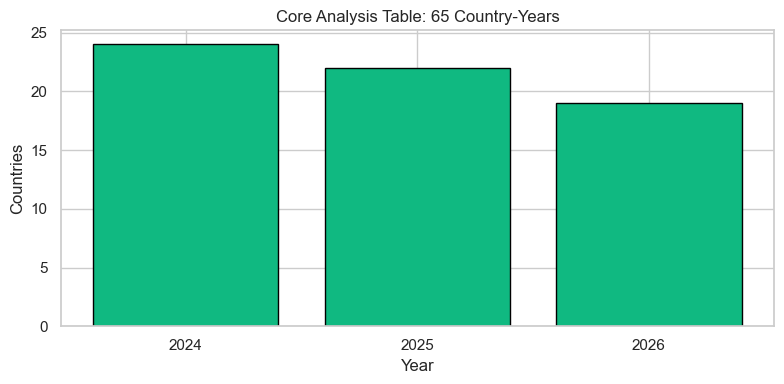

In [13]:
# Build country-year analysis table (HNO need vs HRP requested resources)

# Country name mapping
COD0_COLS = ["ISO3", "Country"]
cod0 = read_hdx_csv(DATA_DIR / "cod_population_admin0.csv", usecols=COD0_COLS)
cod0 = cod0[~cod0["ISO3"].astype(str).str.startswith("#")].copy()
name_map = cod0.drop_duplicates("ISO3")[["ISO3", "Country"]].rename(columns={"ISO3": "iso3", "Country": "country"})

# Extract HNO overall caseload (Cluster='ALL', Category blank)
hno_clean = hno.copy()
hno_clean["Cluster"] = hno_clean["Cluster"].astype(str).str.strip()
hno_clean["Category"] = hno_clean["Category"].fillna("").astype(str).str.strip()

hno_overall = (
 hno_clean.query("Cluster == 'ALL' and Category == ''")
 .rename(columns={"Country ISO3": "iso3", "Population": "population", "In Need": "in_need", "Targeted": "targeted"})
 [["year", "iso3", "population", "in_need", "targeted"]].copy()
)

# HRP: aggregate to country-year, we don't look at plans involving multiple countries
hrp_single = hrp.query("n_locations == 1").copy()
hrp_single = hrp_single.explode("year_list")
hrp_single["year"] = pd.to_numeric(hrp_single["year_list"], errors="coerce")
hrp_single = hrp_single[hrp_single["year"].isin(YEARS)].copy()
hrp_single["year"] = hrp_single["year"].astype(int)
hrp_single["iso3"] = hrp_single["loc_list"].str[0]

hrp_agg = (
 hrp_single.assign(revisedRequirements=hrp_single["revisedRequirements"].fillna(0))
 .groupby(["year", "iso3"], as_index=False)
 .agg(req_sum=("revisedRequirements", "sum"), req_max=("revisedRequirements", "max"), n_plans=("code", "nunique"))
)

# Merge datasets
core = hno_overall.merge(hrp_agg, on=["year", "iso3"], how="left").merge(name_map, on="iso3", how="left")
core["country"] = core["country"].fillna(core["iso3"])
for c in ["req_sum", "req_max", "n_plans"]:
 core[c] = core[c].fillna(0)

# Summary visualization
plt.figure(figsize=(8, 4))

# Records by year
# The plot is jsut a sanity check to see if the conversion was alright, so don't worry about it
year_counts = core.groupby("year").size()
plt.bar(year_counts.index.astype(str), year_counts.values, color="#10b981", edgecolor="black")
plt.title(f"Core Analysis Table: {len(core)} Country-Years")
plt.xlabel("Year")
plt.ylabel("Countries")

plt.tight_layout()
plt.show()


### Derived metrics (country-year)


- **Need intensity**: `need_rate = in_need / population`
- **Operational coverage**: `coverage_rate = targeted / in_need`
- **Resource adequacy (proxy)**: `usd_per_in_need = req_sum / in_need` (requested USD per person in need)
- **People gap**: `funding_gap_people = in_need - targeted`

To compare across countries **within a year** (robust to scale differences), we compute within-year percentile ranks:

- `need_rate_pct = pct_rank(need_rate)`
- `in_need_pct = pct_rank(in_need)`
- `usd_per_in_need_pct = pct_rank(usd_per_in_need)`

Then define mismatch-style scores:

- **Mismatch**: `mismatch = need_rate_pct - usd_per_in_need_pct` (high need + low resources ⇒ higher)

**Important limitation**: `revisedRequirements` are *requested* resources, not confirmed disbursements. We treat them as a consistent proxy and validate patterns against INFORM severity/context.


In [14]:
# Derived metrics + robust percentile scores (computed within-year)

core = core.copy()

# Core ratios
core["need_rate"] = core["in_need"] / core["population"]
core["coverage_rate"] = core["targeted"] / core["in_need"]
core["usd_per_in_need"] = core["req_sum"] / core["in_need"]
core["usd_per_in_need_max"] = core["req_max"] / core["in_need"]
core["req_per_capita"] = core["req_sum"] / core["population"]
core["funding_gap_people"] = core["in_need"] - core["targeted"]

# Clean infinities
for c in ["need_rate", "coverage_rate", "usd_per_in_need", "usd_per_in_need_max", "req_per_capita"]:
 core.loc[~np.isfinite(core[c]), c] = np.nan

# Within-year shares
core["need_share"] = core.groupby("year")["in_need"].transform(lambda s: s / s.sum() if s.sum() else np.nan)
core["req_share"] = core.groupby("year")["req_sum"].transform(lambda s: s / s.sum() if s.sum() else np.nan)
core["share_gap"] = core["need_share"] - core["req_share"]

# Percentile ranks within each year
for raw, pct in {"need_rate": "need_rate_pct", "in_need": "in_need_pct", "usd_per_in_need": "usd_per_in_need_pct"}.items():
 core[pct] = core.groupby("year")[raw].rank(pct=True, method="average")

# Mismatch scores
core["mismatch"] = core["need_rate_pct"] - core["usd_per_in_need_pct"]

# Log transforms
core["log10_in_need"] = np.log10(core["in_need"].where(core["in_need"] > 0))
core["log10_usd_per_in_need"] = np.log10(core["usd_per_in_need"].where(core["usd_per_in_need"] > 0))

# Summary statistics table
metrics_summary = core[["need_rate", "coverage_rate", "usd_per_in_need", "mismatch"]].describe().round(3)
display(metrics_summary.style.format("{:.3f}").set_caption("Key Metrics Summary"))


,need_rate,coverage_rate,usd_per_in_need,mismatch
count,65.000,65.000,65.000,65.000
mean,0.305,0.589,146.224,0.000
std,0.196,0.145,103.119,0.374
min,0.025,0.208,23.661,-0.909
25%,0.152,0.486,93.953,-0.273
50%,0.278,0.618,126.855,0.083
75%,0.461,0.694,177.230,0.273
max,0.723,0.841,721.940,0.737


In [15]:
#Create core_enriched
# Enrich `core` with INFORM severity + crisis context + temporal features.
# This is the dataset used from here on: `core_enriched`.

# --- 1. INFORM severity join, with 2025 fallback for 2026 ---
# INFORM master goes 2020–2025. For 2026 rows we proxy with each country's 2025 values
# (see the note under section 2 about using the most recent available INFORM release).
inform_join = inform_master[[
    "iso3", "year", "severity_index", "severity_category", "trend",
    "region", "crisis_type", "drivers", "primary_driver",
    "complexity", "operating_env",
]].copy()
inform_join["year"] = pd.to_numeric(inform_join["year"], errors="coerce").astype("Int64")

# Build a 2026 shadow from 2025 so the merge finds rows for the current planning year
inform_2025 = inform_join[inform_join["year"] == 2025].copy()
inform_2026_proxy = inform_2025.assign(year=2026)
inform_join_ext = pd.concat([inform_join, inform_2026_proxy], ignore_index=True)

# A country can appear multiple times per year in INFORM (multiple crisis types).
# Collapse to one row per (iso3, year): keep the max severity, concatenate crisis types,
# and take the modal categorical values for the rest.
def _mode_or_first(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

inform_collapsed = (
    inform_join_ext
    .groupby(["iso3", "year"], as_index=False)
    .agg(
        severity_index=("severity_index", "max"),
        severity_category=("severity_category", _mode_or_first),
        trend=("trend", _mode_or_first),
        region=("region", _mode_or_first),
        crisis_type=("crisis_type", lambda s: "|".join(sorted(set(str(x) for x in s.dropna())))),
        drivers=("drivers", _mode_or_first),
        primary_driver=("primary_driver", _mode_or_first),
        complexity=("complexity", "max"),
        operating_env=("operating_env", "max"),
    )
)

core_enriched = core.merge(inform_collapsed, on=["iso3", "year"], how="left")

# --- 2. True severity-weighted mismatch (not the percentile proxy from cell 19) ---
# Rescale INFORM severity (0–5) to a 0–1 weight on the "need" side of the mismatch,
# then keep the same construction as before: severity-weighted need minus resources.
sev_norm = (core_enriched["severity_index"] / 5.0).clip(lower=0, upper=1)
# When INFORM severity is missing, fall back to the percentile severity proxy
# so we don't silently drop country-years from downstream plots.
sev_filled = sev_norm.fillna(0)

core_enriched["mismatch_severity"] = sev_filled - core_enriched["usd_per_in_need_pct"]

# --- 3. Temporal feature: years since the country first had an HRP ---
# Uses the full HRP table (all years, not just 2024–2026) so we catch long-running plans.
hrp_first = (
    hrp.query("n_locations == 1")
       .assign(iso3=lambda d: d["loc_list"].str[0],
               start_year=lambda d: d["startDate"].dt.year)
       .dropna(subset=["iso3", "start_year"])
       .groupby("iso3", as_index=False)["start_year"].min()
       .rename(columns={"start_year": "first_hrp_year"})
)
core_enriched = core_enriched.merge(hrp_first, on="iso3", how="left")
core_enriched["years_since_first_response"] = core_enriched["year"] - core_enriched["first_hrp_year"]

# Sanity check
print(f"core_enriched: {len(core_enriched)} country-years, "
      f"{core_enriched['iso3'].nunique()} countries, "
      f"years {sorted(core_enriched['year'].unique())}")
print(f"  severity_index present:             {core_enriched['severity_index'].notna().sum()}")
print(f"  mismatch_severity present:          {core_enriched['mismatch_severity'].notna().sum()}")
print(f"  years_since_first_response present: {core_enriched['years_since_first_response'].notna().sum()}")
core_enriched.head()

core_enriched: 65 country-years, 24 countries, years [np.int64(2024), np.int64(2025), np.int64(2026)]
  severity_index present:             65
  mismatch_severity present:          65
  years_since_first_response present: 65


,year,iso3,population,in_need,targeted,req_sum,req_max,n_plans,country,need_rate,...,trend,region,crisis_type,drivers,primary_driver,complexity,operating_env,mismatch_severity,first_hrp_year,years_since_first_response
0,2024,AFG,44532600.0,23666389.0,17327995.0,3059587797,3059587797,1,Afghanistan,0.531440,...,Stable,Asia,,"Conflict,Violence,Displacement,Drought,Earthqu...",Conflict,3.9,4.0,0.338333,2001,23
1,2024,BFA,23268117.0,6293939.0,3848843.0,934604385,934604385,1,Burkina Faso,0.270496,...,Stable,Africa,,"Conflict,Displacement,Violence",Conflict,4.0,4.5,0.173333,2007,17
2,2024,CAF,6148956.0,2801810.0,1945532.0,367670976,367670976,1,CAF,0.455656,...,Stable,Africa,,"Conflict,Displacement",Conflict,3.9,4.0,0.216667,2003,21
3,2024,CMR,28600000.0,3369526.0,2302441.0,371369724,371369724,1,Cameroon,0.117816,...,Decreasing,Africa,,Conflict,Conflict,3.9,4.0,0.323333,2014,10
4,2024,COD,113607141.0,25397896.0,8702185.0,2580627746,2580627746,1,Democratic Republic of the Congo,0.223559,...,Stable,Africa,,"Conflict,Displacement,Socio-political",Conflict,4.1,4.0,0.546667,2000,24


# Type A — Invisible crises: 
High INFORM Severity, no HNO or no HRP. These are the most overlooked because they never enter the funding conversation at all. Think Myanmar pre-2021 style situations, or countries where the government blocks HNO processes.


Severity floor: 3.0  |  Severe country-years: 86

Countries by pipeline stage (count, by year):
pipeline_stage  Invisible  Undocumented  In pipeline
year                                                
2024                    8             8           24
2025                   16             9           21

Overlooked countries (severity >= 3.0, not in full pipeline):
 year iso3                               country  severity_index severity_category             primary_driver      trend pipeline_stage has_hno has_hrp  in_need
 2025  ETH                              Ethiopia             4.2         Very High International Displacement     Stable      Invisible   False   False      0.0
 2025  IRN            Iran (Islamic Republic of)             3.9              High International Displacement     Stable      Invisible   False   False      0.0
 2025  PRK Democratic People's Republic of Korea             3.8              High   Drought/drier conditions Increasing      Invisible   False   

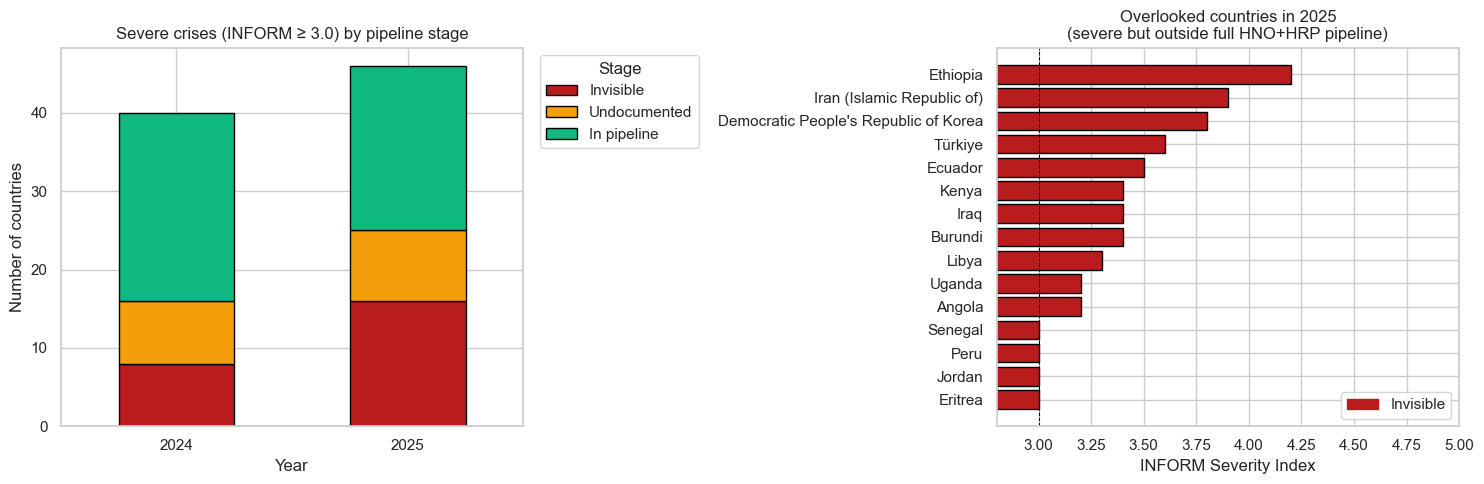


`invisible_cases` DataFrame ready: 24 country-year rows.


In [16]:
# ============================================================
# INVISIBLE CASES: High INFORM severity, absent from HNO / HRP
# ============================================================
# These are the most "overlooked" category of overlooked crises:
# countries that a credible severity index flags as serious, yet
# never enter the humanitarian planning pipeline (no HNO profile,
# no HRP appeal). Because they are not documented, they cannot be
# ranked by a funding-gap ratio — they fall off the dashboard
# entirely. This cell surfaces them explicitly.
#
# Method:
#   1. Take INFORM severity data for the analysis years.
#   2. Keep countries where severity >= a meaningful threshold.
#   3. Flag which of those have an HNO entry (In Need figures)
#      and which have an HRP entry (funding requirement).
#   4. Classify each country-year into a pipeline stage:
#        - Invisible     : severe, no HNO, no HRP
#        - Undocumented  : severe, no HNO, but HRP exists
#        - Unplanned     : severe, HNO exists, no HRP
#        - In pipeline   : severe, both HNO and HRP
#   5. Rank the Invisible + Unplanned countries by severity.

# ---- 1. Severity threshold --------------------------------------------------
# INFORM categorises severity as: Very low (<1), Low (1-2), Medium (2-3),
# High (3-3.5), Very high (3.5-4), and extreme beyond that. We use 3.0 as
# the floor because that is where INFORM's own "High" band starts and where
# humanitarian sector reporting (ECHO FCA, NRC) treats a crisis as serious.
SEVERITY_FLOOR = 3.0
ANALYSIS_YEARS = [2024, 2025]   # INFORM master file ends in 2025; HNO/HRP cover 2024-2026

# ---- 2. Keep the latest available severity per country-year -----------------
# `inform_master` was built earlier in the notebook (iso3, year, severity_index, ...).
sev = (
    inform_master
    .dropna(subset=["severity_index", "iso3", "year"])
    .assign(year=lambda d: d["year"].astype(int))
    .query("year in @ANALYSIS_YEARS")
    .sort_values(["iso3", "year", "severity_index"], ascending=[True, True, False])
    .drop_duplicates(subset=["iso3", "year"], keep="first")
    [["iso3", "year", "country_name", "severity_index", "severity_category",
      "primary_driver", "crisis_type", "region", "trend"]]
)

severe = sev[sev["severity_index"] >= SEVERITY_FLOOR].copy()

# ---- 3. Presence flags from HNO and HRP -------------------------------------
# HNO: a country "has an HNO" in year Y if it appears with a positive In Need
# figure in the overall (Cluster='ALL') caseload.
hno_present = (
    hno_clean
    .query("Cluster == 'ALL' and Category == ''")
    .rename(columns={"Country ISO3": "iso3", "In Need": "in_need"})
    .assign(in_need=lambda d: pd.to_numeric(d["in_need"], errors="coerce"))
    .dropna(subset=["in_need"])
    .query("in_need > 0")
    [["iso3", "year", "in_need"]]
    .drop_duplicates(subset=["iso3", "year"])
)
hno_present["has_hno"] = True

# HRP: presence comes from the already-aggregated hrp_agg table (single-country
# plans only). A country "has an HRP" in year Y if req_sum > 0.
hrp_present = (
    hrp_agg
    .query("req_sum > 0")
    [["iso3", "year", "req_sum"]]
    .drop_duplicates(subset=["iso3", "year"])
)
hrp_present["has_hrp"] = True

# ---- 4. Merge flags onto the severe country-years ---------------------------
overlap = (
    severe
    .merge(hno_present, on=["iso3", "year"], how="left")
    .merge(hrp_present, on=["iso3", "year"], how="left")
)
overlap["has_hno"] = overlap["has_hno"].fillna(False)
overlap["has_hrp"] = overlap["has_hrp"].fillna(False)
overlap["in_need"] = overlap["in_need"].fillna(0)
overlap["req_sum"] = overlap["req_sum"].fillna(0)

def classify_stage(row):
    if not row["has_hno"] and not row["has_hrp"]:
        return "Invisible"          # severe but entirely absent from pipeline
    if not row["has_hno"] and row["has_hrp"]:
        return "Undocumented"       # plan exists without a public needs profile
    if row["has_hno"] and not row["has_hrp"]:
        return "Unplanned"          # needs documented but no appeal launched
    return "In pipeline"

overlap["pipeline_stage"] = overlap.apply(classify_stage, axis=1)

# Prefer a readable country label; fall back to INFORM's own country_name, then iso3.
overlap = overlap.merge(name_map, on="iso3", how="left")
overlap["country"] = overlap["country"].fillna(overlap["country_name"]).fillna(overlap["iso3"])

# ---- 5. Summarise the pipeline-stage breakdown ------------------------------
stage_summary = (
    overlap
    .groupby(["year", "pipeline_stage"], as_index=False)
    .agg(n_countries=("iso3", "nunique"))
    .pivot(index="year", columns="pipeline_stage", values="n_countries")
    .fillna(0)
    .astype(int)
)
# Ensure a stable column order even when a stage has zero countries.
for col in ["Invisible", "Undocumented", "In pipeline"]:
    if col not in stage_summary.columns:
        stage_summary[col] = 0
stage_summary = stage_summary[["Invisible", "Undocumented", "In pipeline"]]

print(f"Severity floor: {SEVERITY_FLOOR}  |  Severe country-years: {len(severe):,}")
print("\nCountries by pipeline stage (count, by year):")
print(stage_summary.to_string())

# ---- 6. The ranked list of overlooked countries -----------------------------
# "Overlooked" here means Invisible or Unplanned: the crisis is severe but
# the humanitarian system has not translated that severity into a funded plan.
overlooked = (
    overlap
    .query("pipeline_stage in ['Invisible', 'Unplanned']")
    .sort_values(["year", "severity_index"], ascending=[False, False])
    [["year", "iso3", "country", "severity_index", "severity_category",
      "primary_driver", "trend", "pipeline_stage", "has_hno", "has_hrp", "in_need"]]
    .reset_index(drop=True)
)

print(f"\nOverlooked countries (severity >= {SEVERITY_FLOOR}, not in full pipeline):")
print(overlooked.head(25).to_string(index=False))

# ---- 7. Visualise the pipeline-stage breakdown ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked bar of pipeline stages per year
stage_colors = {
    "Invisible":    "#b91c1c",   # dark red — most concerning
    "Unplanned":    "#ef4444",   # red
    "Undocumented": "#f59e0b",   # amber
    "In pipeline":  "#10b981",   # green
}
stage_summary.plot(
    kind="bar", stacked=True, ax=axes[0],
    color=[stage_colors[c] for c in stage_summary.columns],
    edgecolor="black",
)
axes[0].set_title(f"Severe crises (INFORM ≥ {SEVERITY_FLOOR}) by pipeline stage")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of countries")
axes[0].legend(title="Stage", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=0)

# Right: top overlooked countries in the most recent year, coloured by stage
latest_year = overlooked["year"].max()
latest_overlooked = (
    overlooked[overlooked["year"] == latest_year]
    .sort_values("severity_index", ascending=True)   # ascending so largest is on top
    .tail(15)
)
bar_colors = latest_overlooked["pipeline_stage"].map(stage_colors)
axes[1].barh(latest_overlooked["country"], latest_overlooked["severity_index"],
             color=bar_colors, edgecolor="black")
axes[1].set_xlim(SEVERITY_FLOOR - 0.2, 5.0)
axes[1].axvline(SEVERITY_FLOOR, color="black", linestyle="--", linewidth=0.7)
axes[1].set_title(f"Overlooked countries in {latest_year}\n(severe but outside full HNO+HRP pipeline)")
axes[1].set_xlabel("INFORM Severity Index")

# Custom legend for the right panel
from matplotlib.patches import Patch
axes[1].legend(
    handles=[Patch(color=stage_colors[s], label=s) for s in ["Invisible"]],
    loc="lower right",
)

plt.tight_layout()
plt.show()

# ---- 8. Export for downstream use -------------------------------------------
# Make the results available to later cells (e.g. joining with CERF/CBPF to see
# whether any pooled funding reaches these invisible/unplanned cases).
invisible_cases = overlooked.copy()
print(f"\n`invisible_cases` DataFrame ready: {len(invisible_cases):,} country-year rows.")


# Type B — Documented but unplanned: 

HNO exists with large PiN, but no HRP or a severely undersized HRP relative to need. The gap is political/diplomatic.

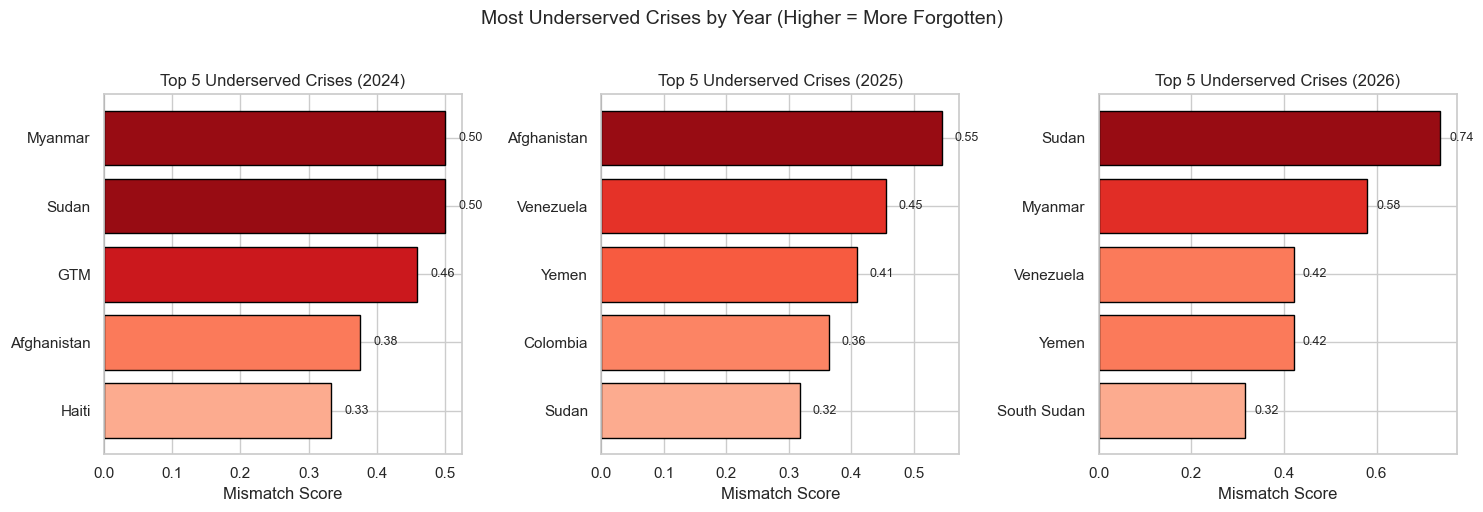

In [17]:
from matplotlib.colors import Normalize

# EDA: Top underserved crises by year (highest mismatch = most "forgotten")
# ISO3 to country name mapping
country_names = {
    "SDN": "Sudan", "MMR": "Myanmar", "AFG": "Afghanistan", "YEM": "Yemen",
    "SYR": "Syria", "COD": "DR Congo", "SSD": "South Sudan", "HTI": "Haiti",
    "VEN": "Venezuela", "COL": "Colombia", "NGA": "Nigeria", "MLI": "Mali",
    "ETH": "Ethiopia", "BGD": "Bangladesh", "PSE": "Palestine", "UKR": "Ukraine"
}
core["country"] = core["iso3"].map(country_names).fillna(core["iso3"])

# Create visualization: Top 5 underserved by year
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, year in enumerate(YEARS):
    ax = axes[idx]
    df_year = core[core["year"] == year].nlargest(5, "mismatch")

    # Map color intensity to mismatch value: higher mismatch → darker red
    norm = Normalize(vmin=df_year["mismatch"].min(),
                     vmax=df_year["mismatch"].max())
    colors = plt.cm.Reds(0.3 + 0.6 * norm(df_year["mismatch"]))

    bars = ax.barh(df_year["country"], df_year["mismatch"],
                   color=colors, edgecolor="black")
    ax.set_xlabel("Mismatch Score")
    ax.set_title(f"Top 5 Underserved Crises ({year})")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.invert_yaxis()  # worst at top

    # Add value labels
    for bar, val in zip(bars, df_year["mismatch"]):
        ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)

plt.suptitle("Most Underserved Crises by Year (Higher = More Forgotten)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Print all of the categories in core, more readable than info() for quick scanning:
print(core.dtypes.to_string())

year                       int64
iso3                         str
population               float64
in_need                  float64
targeted                 float64
req_sum                    int64
req_max                    int64
n_plans                    int64
country                      str
need_rate                float64
coverage_rate            float64
usd_per_in_need          float64
usd_per_in_need_max      float64
req_per_capita           float64
funding_gap_people       float64
need_share               float64
req_share                float64
share_gap                float64
need_rate_pct            float64
in_need_pct              float64
usd_per_in_need_pct      float64
mismatch                 float64
log10_in_need            float64
log10_usd_per_in_need    float64


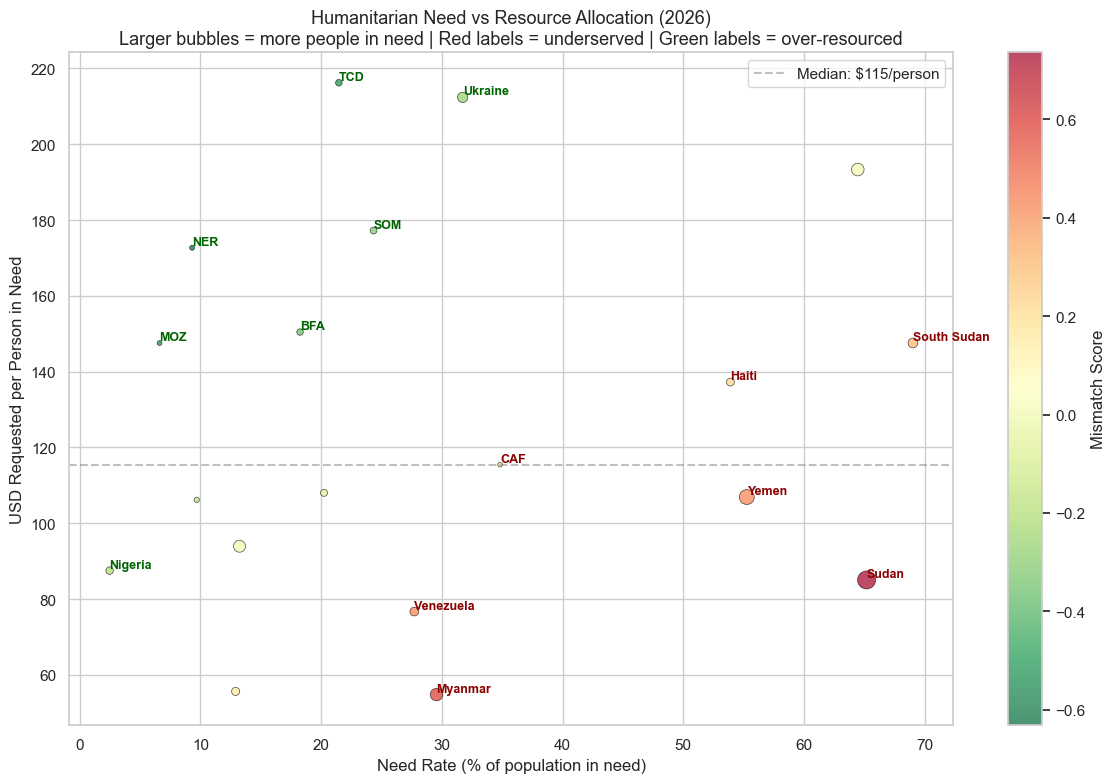

2026 — Most underserved (highest mismatch):
    country  need_rate  usd_per_in_need  mismatch
      Sudan      0.652           85.052     0.737
    Myanmar      0.296           54.815     0.579
  Venezuela      0.277           76.709     0.421
      Yemen      0.553          106.926     0.421
South Sudan      0.690          147.576     0.316
        CAF      0.348          115.480     0.211
      Haiti      0.539          137.247     0.211

2026 — Most over-resourced (lowest mismatch):
country  need_rate  usd_per_in_need  mismatch
    NER      0.093          172.692    -0.632
    TCD      0.215          216.234    -0.526
    MOZ      0.066          147.549    -0.526
    BFA      0.183          150.455    -0.368
    SOM      0.243          177.230    -0.316
Ukraine      0.317          212.353    -0.263
Nigeria      0.025           87.525    -0.211



In [19]:
def plot_need_vs_resources(core, year, n_labels=7):
    """Scatter of need rate vs resources per person in need for a given year.

    Labels the top-N underserved (highest mismatch) in red and the top-N
    over-resourced (lowest mismatch) in green.

    Parameters
    ----------
    core : pd.DataFrame
        Must contain: year, country, need_rate, usd_per_in_need, in_need, mismatch.
    year : int
        Year to plot.
    n_labels : int
        How many countries to label at each tail.
    """
    df_year = core[core["year"] == year].copy()

    if df_year.empty:
        print(f"No data available for {year}.")
        return

    fig, ax = plt.subplots(figsize=(12, 8))

    scatter = ax.scatter(
        df_year["need_rate"] * 100,
        df_year["usd_per_in_need"],
        s=df_year["in_need"] / 1e6 * 5,   # size by people in need
        c=df_year["mismatch"],
        cmap="RdYlGn_r",
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5,
    )

    # Label top-N underserved (highest mismatch) — red end
    for _, row in df_year.nlargest(n_labels, "mismatch").iterrows():
        ax.annotate(
            row["country"],
            (row["need_rate"] * 100, row["usd_per_in_need"]),
            fontsize=9, ha="left", va="bottom",
            color="#8b0000", fontweight="bold",
        )

    # Label bottom-N over-resourced (lowest mismatch) — green end
    for _, row in df_year.nsmallest(n_labels, "mismatch").iterrows():
        ax.annotate(
            row["country"],
            (row["need_rate"] * 100, row["usd_per_in_need"]),
            fontsize=9, ha="left", va="bottom",
            color="#006400", fontweight="bold",
        )

    # Reference line
    median_usd = df_year["usd_per_in_need"].median()
    ax.axhline(
        median_usd, color="gray", linestyle="--", alpha=0.5,
        label=f"Median: ${median_usd:.0f}/person",
    )

    ax.set_xlabel("Need Rate (% of population in need)", fontsize=12)
    ax.set_ylabel("USD Requested per Person in Need", fontsize=12)
    ax.set_title(
        f"Humanitarian Need vs Resource Allocation ({year})\n"
        "Larger bubbles = more people in need | "
        "Red labels = underserved | Green labels = over-resourced",
        fontsize=13,
    )
    ax.legend(loc="upper right")
    plt.colorbar(scatter, ax=ax, label="Mismatch Score")
    plt.tight_layout()
    plt.show()

    # Print both tails
    print(f"{year} — Most underserved (highest mismatch):")
    print(df_year.nlargest(n_labels, "mismatch")[
        ["country", "need_rate", "usd_per_in_need", "mismatch"]
    ].round(3).to_string(index=False))

    print(f"\n{year} — Most over-resourced (lowest mismatch):")
    print(df_year.nsmallest(n_labels, "mismatch")[
        ["country", "need_rate", "usd_per_in_need", "mismatch"]
    ].round(3).to_string(index=False))
    print()   # blank line between years


# Run for each year
plot_need_vs_resources(core, 2026)

# Type C — Planned but unfunded: 
HRP exists with realistic requirements, but FTS coverage is low. This is the classic "funding gap" ratio.


HRP funding coverage — 2026
Countries with an HRP: 19   |   Median coverage (paid+committed): 11.6%

Least-funded HRPs in 2026:


Country,In Need,HRP Ask,Paid,Committed,Pledged,Coverage,Coverage (paid only)
BFA,4.4M,$662.0M,$18.6M,$6.0M,$1.6M,3.7%,2.8%
CAF,2.3M,$264.1M,$8.6M,$1.3M,$321K,3.7%,3.2%
Yemen,23.1M,$2.5B,$83.6M,$18.7M,$2.8M,4.1%,3.4%
SOM,4.8M,$850.0M,$23.5M,$13.4M,$4.2M,4.3%,2.8%
Mali,5.1M,$551.0M,$20.0M,$5.2M,$2.0M,4.6%,3.6%
NER,2.6M,$449.0M,$21.0M,$9.8M,$2.3M,6.9%,4.7%
Syria,16.5M,$3.2B,$210.5M,$16.4M,$1.7M,7.1%,6.6%
South Sudan,9.9M,$1.5B,$112.5M,$9.7M,$1.4M,8.4%,7.7%
Venezuela,7.9M,$606.0M,$57.9M,$2.2M,$0,9.9%,9.6%
Sudan,33.7M,$2.9B,$295.2M,$38.4M,$3.6M,11.6%,10.3%


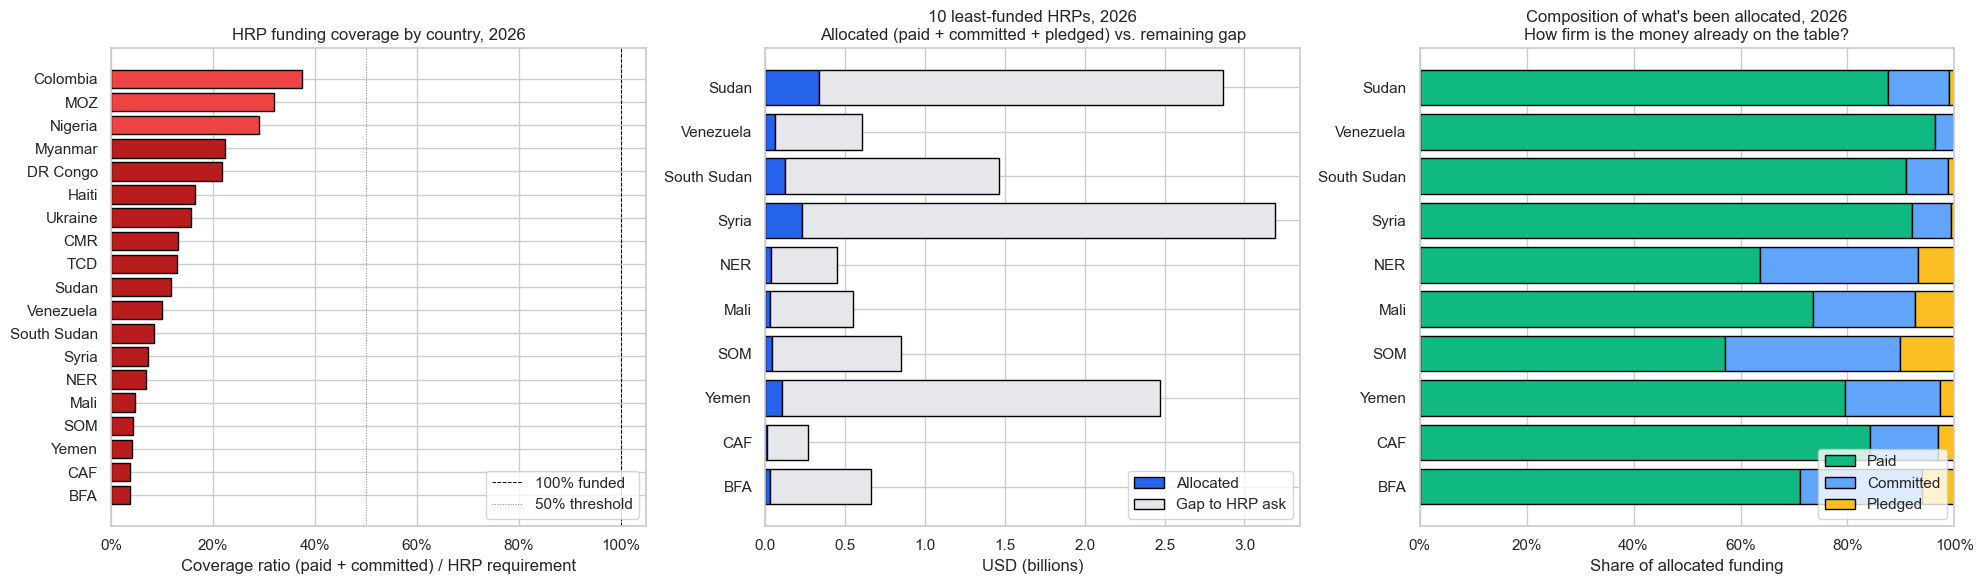


`hrp_fts` DataFrame ready: 65 country-year rows (65 with an HRP).


In [20]:
# ============================================================
# HRP FUNDING COVERAGE: what was requested vs. what arrived (FTS)
# ============================================================
# Type C in our pipeline taxonomy: the HRP exists with a credible
# requirement, but the funding that actually flows in (tracked by
# OCHA's Financial Tracking Service) falls short. This cell joins
# the HRP requirements from `core` with FTS contribution records
# to produce a country-year HRP coverage ratio.
#
# Why this matters: `req_sum` tells us what was asked for; FTS
# tells us what donors actually moved. The ratio of the two is
# the most widely reported "funding gap" figure in the sector
# (it is what OCHA's Global Humanitarian Overview quotes).
#
# Important subtlety we handle:
#   - "paid" = disbursed cash
#   - "commitment" = legally binding promise
#   - "pledge" = non-binding intent
# We report all three separately AND a conservative total that
# excludes pledges, since pledges frequently do not materialise.

FTS_PATH = DATA_DIR / "fts_outgoing_funding_global.csv"
COVERAGE_YEARS = [2024, 2025, 2026]

# ---- 1. Load FTS contributions ---------------------------------------------
fts_raw = pd.read_csv(FTS_PATH, low_memory=False)

# Pick the best available allocation year for each record:
#   budgetYear is populated for ~94% of rows; fall back to destUsageYearStart.
fts = fts_raw.copy()
fts["year"] = pd.to_numeric(fts["budgetYear"], errors="coerce")
fts["year"] = fts["year"].fillna(pd.to_numeric(fts["destUsageYearStart"], errors="coerce"))
fts = fts.dropna(subset=["year"])
fts["year"] = fts["year"].astype(int)
fts = fts[fts["year"].isin(COVERAGE_YEARS)].copy()

# Amount must be numeric. Negative amounts (refunds / reversals) are kept so
# that the net flow is correct, but they are rare (~1% of rows).
fts["amountUSD"] = pd.to_numeric(fts["amountUSD"], errors="coerce").fillna(0)

# Drop the 40-or-so shared / multi-country rows to avoid double-counting a
# single regional contribution against several national plans. `onBoundary`
# flags these explicitly.
fts = fts[fts["onBoundary"] == "single"].copy()

# Resolve the country ISO3. For the remaining single-destination rows we take
# `destLocations`; a tiny handful are still comma-separated regional appeals
# (e.g. Sahel), which we exclude from country-level coverage because they
# cannot be fairly attributed to one country.
fts["iso3"] = fts["destLocations"].astype(str).str.strip()
fts = fts[fts["iso3"].str.len() == 3].copy()   # keeps clean 3-letter ISO codes only

# ---- 2. Aggregate funding by country, year and status -----------------------
# We keep the three FTS statuses separate because their reliability differs.
funding_by_status = (
    fts.groupby(["iso3", "year", "status"], as_index=False)["amountUSD"].sum()
    .pivot_table(index=["iso3", "year"], columns="status", values="amountUSD", fill_value=0)
    .reset_index()
)
# Make sure all three columns exist even if a status is missing in the slice
for s in ["paid", "commitment", "pledge"]:
    if s not in funding_by_status.columns:
        funding_by_status[s] = 0.0
funding_by_status = funding_by_status.rename(columns={
    "paid": "fts_paid",
    "commitment": "fts_commitment",
    "pledge": "fts_pledge",
})

# Conservative total = paid + commitment (excludes non-binding pledges)
funding_by_status["fts_funded"] = funding_by_status["fts_paid"] + funding_by_status["fts_commitment"]
# Optimistic total = everything reported
funding_by_status["fts_total_reported"] = (
    funding_by_status["fts_paid"]
    + funding_by_status["fts_commitment"]
    + funding_by_status["fts_pledge"]
)

# ---- 3. Join with HRP requirements from the core table ----------------------
# `core` already has req_sum (HRP revisedRequirements, USD) per iso3-year.
hrp_fts = (
    core[["iso3", "country", "year", "in_need", "req_sum"]]
    .merge(funding_by_status, on=["iso3", "year"], how="left")
)
for c in ["fts_paid", "fts_commitment", "fts_pledge", "fts_funded", "fts_total_reported"]:
    hrp_fts[c] = hrp_fts[c].fillna(0)

# Only compute coverage for countries that actually have an HRP (req_sum > 0)
# — otherwise the ratio is meaningless. Countries with req_sum == 0 belong to
# the invisible/unplanned categories handled earlier.
has_hrp = hrp_fts["req_sum"] > 0
hrp_fts["coverage_ratio"] = np.where(
    has_hrp, hrp_fts["fts_funded"] / hrp_fts["req_sum"], np.nan
)
hrp_fts["coverage_ratio_paid_only"] = np.where(
    has_hrp, hrp_fts["fts_paid"] / hrp_fts["req_sum"], np.nan
)
hrp_fts["funding_gap_usd"] = np.where(
    has_hrp, (hrp_fts["req_sum"] - hrp_fts["fts_funded"]).clip(lower=0), np.nan
)

# ---- 4. Rank the most underfunded HRPs in the latest year -------------------
latest = hrp_fts["year"].max()
latest_view = (
    hrp_fts.query("year == @latest and req_sum > 0")
    .sort_values("coverage_ratio", ascending=True)
    .copy()
)

print(f"HRP funding coverage — {latest}")
print(f"Countries with an HRP: {len(latest_view)}   |   "
      f"Median coverage (paid+committed): {latest_view['coverage_ratio'].median():.1%}")

display_cols = ["country", "in_need", "req_sum", "fts_paid", "fts_commitment",
                "fts_pledge", "coverage_ratio", "coverage_ratio_paid_only"]
bottom = latest_view.head(15)[display_cols].copy()
bottom["in_need"] = bottom["in_need"].apply(format_num)
bottom["req_sum"] = bottom["req_sum"].apply(lambda x: "$" + format_num(x))
for c in ["fts_paid", "fts_commitment", "fts_pledge"]:
    bottom[c] = bottom[c].apply(lambda x: "$" + format_num(x))
bottom["coverage_ratio"] = (bottom["coverage_ratio"] * 100).round(1).astype(str) + "%"
bottom["coverage_ratio_paid_only"] = (bottom["coverage_ratio_paid_only"] * 100).round(1).astype(str) + "%"
bottom = bottom.rename(columns={
    "country": "Country", "in_need": "In Need", "req_sum": "HRP Ask",
    "fts_paid": "Paid", "fts_commitment": "Committed", "fts_pledge": "Pledged",
    "coverage_ratio": "Coverage", "coverage_ratio_paid_only": "Coverage (paid only)",
})
print(f"\nLeast-funded HRPs in {latest}:")
display(bottom.style.hide(axis="index")
        .set_caption(f"HRP funding coverage {latest} — ranked by paid+committed / requested"))

# ---- 5. Visualise the coverage — three complementary views ----------------
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Panel A: ranked coverage ratio for every HRP country ------------------
rank_df = latest_view.sort_values("coverage_ratio", ascending=True)
bar_colors = ["#b91c1c" if r < 0.25 else "#ef4444" if r < 0.50
              else "#f59e0b" if r < 0.75 else "#10b981"
              for r in rank_df["coverage_ratio"]]
axes[0].barh(rank_df["country"], rank_df["coverage_ratio"],
             color=bar_colors, edgecolor="black")
axes[0].axvline(1.0, color="black", linestyle="--", linewidth=0.7,
                label="100% funded")
axes[0].axvline(0.50, color="gray", linestyle=":", linewidth=0.7,
                label="50% threshold")
axes[0].set_xlabel("Coverage ratio (paid + committed) / HRP requirement")
axes[0].set_title(f"HRP funding coverage by country, {latest}")
axes[0].legend(loc="lower right")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# --- Panel B: allocated vs. gap, in absolute USD (billions) ----------------
# "Allocated" = paid + committed + pledged, i.e. everything the donor system
# has signalled it will move, regardless of whether the cash has arrived. The
# gap is what's still missing against the HRP requirement.
worst10 = latest_view.head(10).sort_values("coverage_ratio", ascending=True)
allocated = worst10["fts_total_reported"] / 1e9   # paid + commit + pledge
gap       = (worst10["req_sum"] - worst10["fts_total_reported"]).clip(lower=0) / 1e9

y = np.arange(len(worst10))
axes[1].barh(y, allocated, color="#2563eb", edgecolor="black", label="Allocated")
axes[1].barh(y, gap, left=allocated, color="#e5e7eb",
             edgecolor="black", label="Gap to HRP ask")
axes[1].set_yticks(y)
axes[1].set_yticklabels(worst10["country"])
axes[1].set_xlabel("USD (billions)")
axes[1].set_title(f"10 least-funded HRPs, {latest}\n"
                  "Allocated (paid + committed + pledged) vs. remaining gap")
axes[1].legend(loc="lower right")

# --- Panel C: composition of the allocated portion (100%-stacked) ----------
# This answers the follow-up question panel B can't: of the money that HAS
# been allocated, how firm is it? Paid is cash in hand, committed is legally
# binding, pledged is intent that often doesn't materialise. A country whose
# allocation is mostly pledges is more fragile than one whose allocation is
# mostly paid, even at the same absolute level.
alloc_total = worst10["fts_total_reported"].replace(0, np.nan)   # avoid 0-div
paid_frac    = worst10["fts_paid"]       / alloc_total
commit_frac  = worst10["fts_commitment"] / alloc_total
pledge_frac  = worst10["fts_pledge"]     / alloc_total

axes[2].barh(y, paid_frac, color="#10b981", edgecolor="black", label="Paid")
axes[2].barh(y, commit_frac, left=paid_frac, color="#60a5fa",
             edgecolor="black", label="Committed")
axes[2].barh(y, pledge_frac, left=paid_frac + commit_frac, color="#fbbf24",
             edgecolor="black", label="Pledged")
axes[2].set_yticks(y)
axes[2].set_yticklabels(worst10["country"])
axes[2].set_xlim(0, 1)
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_xlabel("Share of allocated funding")
axes[2].set_title(f"Composition of what's been allocated, {latest}\n"
                  "How firm is the money already on the table?")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

# ---- 6. Keep the joined table available to later cells ----------------------
print(f"\n`hrp_fts` DataFrame ready: {len(hrp_fts):,} country-year rows "
      f"({(hrp_fts['req_sum'] > 0).sum():,} with an HRP).")

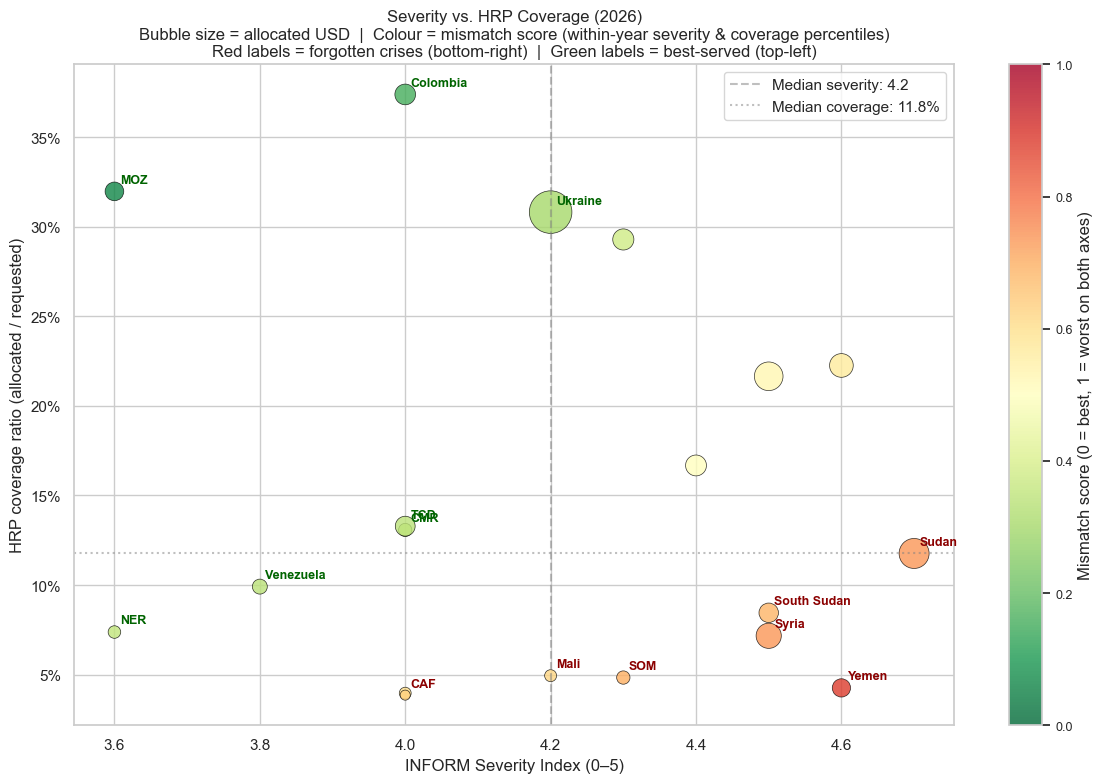

2026 — Top 7 by severity-coverage mismatch score (most forgotten):
    Country  Severity Sev %ile HRP Ask Allocated Coverage Cov %ile  Mismatch
      Yemen       4.6      92%   $2.5B   $105.1M     4.3%      16%     0.882
      Sudan       4.7     100%   $2.9B   $337.1M    11.8%      53%     0.737
      Syria       4.5      79%   $3.2B   $228.6M     7.2%      32%     0.737
        SOM       4.3      61% $850.0M    $41.1M     4.8%      21%     0.697
South Sudan       4.5      79%   $1.5B   $123.6M     8.4%      42%     0.684
        CAF       4.0      32% $264.1M    $10.2M     3.9%       5%     0.632
       Mali       4.2      50% $551.0M    $27.2M     4.9%      26%     0.618

2026 — Bottom 7 by severity-coverage mismatch score (best-served):
  Country  Severity Sev %ile HRP Ask Allocated Coverage Cov %ile  Mismatch
      MOZ       3.6       8% $347.6M   $111.2M    32.0%      95%     0.066
 Colombia       4.0      32% $384.0M   $143.6M    37.4%     100%     0.158
  Ukraine       4.2     

In [21]:
# ============================================================
# SCATTER: INFORM SEVERITY vs. HRP COVERAGE RATIO
# ============================================================
# Companion to `plot_need_vs_resources`. The Y axis is the HRP
# coverage ratio — what fraction of the ask was allocated — so
# LOW on the Y axis = bad. Together with severity on X, the
# bottom-right corner is the "forgotten crisis" quadrant:
# high severity, low coverage.
#
#   X     : INFORM Severity Index (0–5)
#   Y     : HRP coverage ratio = allocated / req_sum  (0 to 1+, higher = better)
#   Size  : allocated USD (paid + committed + pledged)
#   Colour: mismatch score = (sev_pct + (1 − cov_pct)) / 2, within-year
#           percentiles. 0 = best, 1 = worst on both axes.
#
# Mismatch reasoning: we use coverage-percentile here (rather than
# gap-percentile) so the colour channel is consistent with the Y
# axis. Both encode "how well funded is this country relative to
# its ask" — gap in absolute dollars favours big HRPs; coverage
# ratio is size-normalised, which matches what the chart shows.

def plot_severity_vs_coverage(hrp_fts, core_enriched, year, n_labels=7):
    """Scatter of INFORM severity vs. HRP coverage ratio for a given year.

    Colour encodes a within-year mismatch score combining severity rank
    and inverse-coverage rank. High mismatch (red) = worst on both axes,
    which now lands in the BOTTOM-right corner (high severity, low coverage).

    Parameters
    ----------
    hrp_fts : pd.DataFrame
        Output of the HRP-FTS coverage cell. Must contain:
        iso3, year, country, req_sum, fts_total_reported, coverage_ratio.
    core_enriched : pd.DataFrame
        Must contain iso3, year, severity_index (INFORM-derived).
    year : int
        Year to plot.
    n_labels : int
        How many of the highest-mismatch countries to label.
    """
    # Merge severity onto hrp_fts for the requested year
    sev = core_enriched[["iso3", "year", "severity_index"]].dropna(
        subset=["severity_index"]
    )
    df = (
        hrp_fts.query("year == @year and req_sum > 0")
        .merge(sev, on=["iso3", "year"], how="left")
        .dropna(subset=["severity_index"])
        .copy()
    )
    if df.empty:
        print(f"No country-years with both severity and HRP data in {year}.")
        return

    # Allocated = paid + committed + pledged. Coverage ratio is already on
    # hrp_fts from the upstream cell; recompute from the 'allocated' total
    # so the Y axis and the mismatch colour are using the same definition.
    df["allocated_usd"] = df["fts_total_reported"]
    df["cov_ratio"] = df["allocated_usd"] / df["req_sum"]

    # Within-year percentile ranks. sev_pct: higher = more severe. cov_pct:
    # higher = better covered. Mismatch flips cov_pct so "high score = bad."
    df["sev_pct"] = df["severity_index"].rank(pct=True, method="average")
    df["cov_pct"] = df["cov_ratio"].rank(pct=True, method="average")
    df["mismatch_sev_cov"] = (df["sev_pct"] + (1 - df["cov_pct"])) / 2

    # Bubble size: allocated USD
    max_alloc = df["allocated_usd"].max()
    df["bubble_size"] = 40 + (df["allocated_usd"] / max_alloc) * 900 if max_alloc > 0 else 80

    fig, ax = plt.subplots(figsize=(12, 8))

    scatter = ax.scatter(
        df["severity_index"],
        df["cov_ratio"] * 100,    # show coverage as a percentage
        s=df["bubble_size"],
        c=df["mismatch_sev_cov"],
        cmap="RdYlGn_r",
        alpha=0.8,
        edgecolors="black",
        linewidth=0.5,
        vmin=0, vmax=1,
    )

    # Label the N highest-mismatch countries — they now sit in the
    # bottom-right (high severity, low coverage). Red labels.
    for _, row in df.nlargest(n_labels, "mismatch_sev_cov").iterrows():
        ax.annotate(
            row["country"],
            (row["severity_index"], row["cov_ratio"] * 100),
            fontsize=9, ha="left", va="bottom",
            color="#8b0000", fontweight="bold",
            xytext=(4, 4), textcoords="offset points",
        )

    # Label the N lowest-mismatch countries — the best-served, sitting
    # toward the top-left (low severity or high coverage). Green labels,
    # matching the convention in `plot_need_vs_resources`.
    for _, row in df.nsmallest(n_labels, "mismatch_sev_cov").iterrows():
        ax.annotate(
            row["country"],
            (row["severity_index"], row["cov_ratio"] * 100),
            fontsize=9, ha="left", va="bottom",
            color="#006400", fontweight="bold",
            xytext=(4, 4), textcoords="offset points",
        )

    # Reference lines
    median_sev = df["severity_index"].median()
    median_cov = df["cov_ratio"].median() * 100
    ax.axvline(median_sev, color="gray", linestyle="--", alpha=0.5,
               label=f"Median severity: {median_sev:.1f}")
    ax.axhline(median_cov, color="gray", linestyle=":", alpha=0.5,
               label=f"Median coverage: {median_cov:.1f}%")

    # Percent formatting on the Y axis
    import matplotlib.ticker as mtick
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

    ax.set_xlabel("INFORM Severity Index (0–5)", fontsize=12)
    ax.set_ylabel("HRP coverage ratio (allocated / requested)", fontsize=12)
    ax.set_title(
        f"Severity vs. HRP Coverage ({year})\n"
        "Bubble size = allocated USD  |  "
        "Colour = mismatch score (within-year severity & coverage percentiles)\n"
        "Red labels = forgotten crises (bottom-right)  |  Green labels = best-served (top-left)",
        fontsize=12,
    )
    ax.legend(loc="upper right")

    cbar = plt.colorbar(scatter, ax=ax, label="Mismatch score (0 = best, 1 = worst on both axes)")
    cbar.ax.tick_params(labelsize=9)

    plt.tight_layout()
    plt.show()

    # Print the highest-mismatch countries
    print(f"{year} — Top {n_labels} by severity-coverage mismatch score "
          "(most forgotten):")
    top = df.nlargest(n_labels, "mismatch_sev_cov")[
        ["country", "severity_index", "sev_pct", "req_sum", "allocated_usd",
         "cov_ratio", "cov_pct", "mismatch_sev_cov"]
    ].copy()
    top["req_sum"]          = top["req_sum"].apply(lambda x: "$" + format_num(x))
    top["allocated_usd"]    = top["allocated_usd"].apply(lambda x: "$" + format_num(x))
    top["cov_ratio"]        = (top["cov_ratio"] * 100).round(1).astype(str) + "%"
    top["severity_index"]   = top["severity_index"].round(2)
    top["sev_pct"]          = (top["sev_pct"] * 100).round(0).astype(int).astype(str) + "%"
    top["cov_pct"]          = (top["cov_pct"] * 100).round(0).astype(int).astype(str) + "%"
    top["mismatch_sev_cov"] = top["mismatch_sev_cov"].round(3)
    top = top.rename(columns={
        "country": "Country", "severity_index": "Severity", "sev_pct": "Sev %ile",
        "req_sum": "HRP Ask", "allocated_usd": "Allocated",
        "cov_ratio": "Coverage", "cov_pct": "Cov %ile",
        "mismatch_sev_cov": "Mismatch",
    })
    print(top.to_string(index=False))

    # And the lowest-mismatch tail — best-served (low severity or high
    # coverage relative to peers).
    print(f"\n{year} — Bottom {n_labels} by severity-coverage mismatch score "
          "(best-served):")
    bot = df.nsmallest(n_labels, "mismatch_sev_cov")[
        ["country", "severity_index", "sev_pct", "req_sum", "allocated_usd",
         "cov_ratio", "cov_pct", "mismatch_sev_cov"]
    ].copy()
    bot["req_sum"]          = bot["req_sum"].apply(lambda x: "$" + format_num(x))
    bot["allocated_usd"]    = bot["allocated_usd"].apply(lambda x: "$" + format_num(x))
    bot["cov_ratio"]        = (bot["cov_ratio"] * 100).round(1).astype(str) + "%"
    bot["severity_index"]   = bot["severity_index"].round(2)
    bot["sev_pct"]          = (bot["sev_pct"] * 100).round(0).astype(int).astype(str) + "%"
    bot["cov_pct"]          = (bot["cov_pct"] * 100).round(0).astype(int).astype(str) + "%"
    bot["mismatch_sev_cov"] = bot["mismatch_sev_cov"].round(3)
    bot = bot.rename(columns={
        "country": "Country", "severity_index": "Severity", "sev_pct": "Sev %ile",
        "req_sum": "HRP Ask", "allocated_usd": "Allocated",
        "cov_ratio": "Coverage", "cov_pct": "Cov %ile",
        "mismatch_sev_cov": "Mismatch",
    })
    print(bot.to_string(index=False))


# Run for the latest year
plot_severity_vs_coverage(hrp_fts, core_enriched, 2026)

# Type D — Pooled-fund orphans: 
FTS coverage is moderate but CBPF/CERF allocation is negligible — meaning donors fund it bilaterally but the flexible, rapid-response pools skip it.

Funding channel breakdown (all years in file):
           channel  n_rows total_usd
Bilateral / agency    3067     $5.2B
              CBPF      97     $2.1B
              CERF      10   $177.9M
      Other pooled      25    $59.7M

CERF in this file: $177.9M across 10 rows.
  Attributable to a specific country: $0.0M
  Global / unattributed in this file: $177.9M
  Note: CERF allocations to countries are recorded more completely in
        the CERF Donor Contributions and Allocations dataset you loaded
        earlier — this file only sees the donor-to-CERF side.

Top 15 FTS recipients by channel:


Country,Total,Bilateral,CBPF,CERF,% pooled
UKR,$813.4M,$629.9M,$183.6M,$0,22.6%
Sudan,$355.7M,$129.7M,$226.1M,$0,63.5%
Democratic Republic of the Congo,$319.1M,$165.3M,$153.8M,$0,48.2%
SYR,$281.0M,$104.9M,$176.1M,$0,62.7%
Bangladesh,$231.0M,$81.0M,$150.0M,$0,64.9%
State of Palestine,$223.7M,$210.0M,$13.7M,$0,6.1%
Ethiopia,$214.0M,$101.2M,$112.7M,$0,52.7%
MMR,$187.5M,$38.7M,$148.8M,$0,79.4%
Nigeria,$155.1M,$27.8M,$127.3M,$0,82.1%
Haiti,$150.9M,$25.2M,$125.6M,$0,83.3%


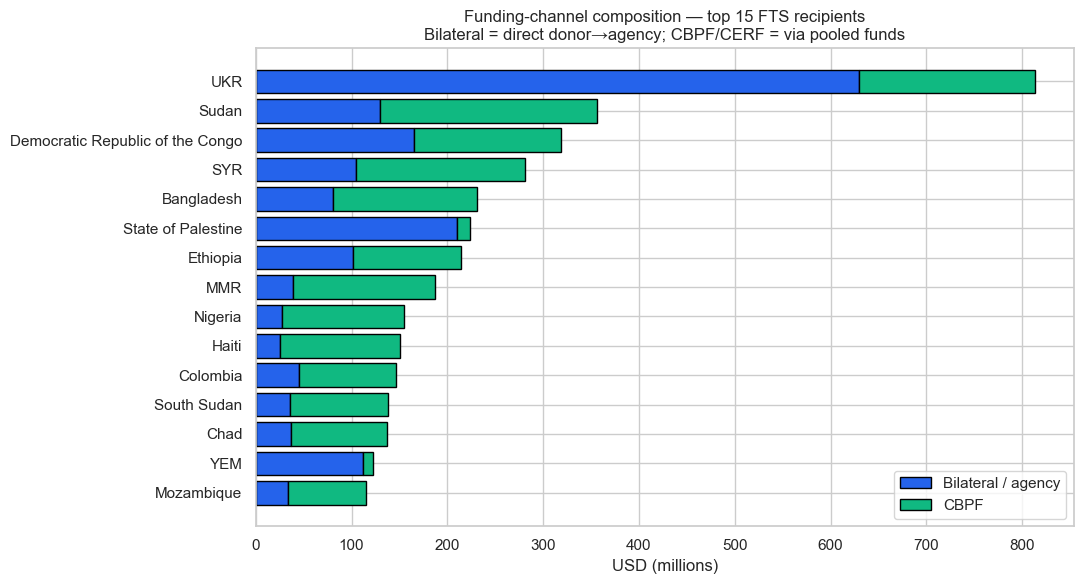


`fts_by_channel` DataFrame ready: 114 countries, columns: bilateral_usd, cbpf_usd, cerf_usd, total_usd, pct_pooled.


In [22]:
# ============================================================
# CBPF AND CERF FLOWS IN THE FTS FILE
# ============================================================
# The FTS file distinguishes pooled-fund flows from bilateral
# flows via the destOrganizationTypes column. Pooled-fund rows
# can be further split into:
#   - CERF   : Central Emergency Response Fund (global, rapid)
#   - CBPF   : Country-Based Pooled Funds — "<Country> Humanitarian
#              Fund" or regional "<Country> (<Region> HF)" format.
#   - Other  : IFRC DREF, UN multi-partner trust funds, Women's
#              Peace & Humanitarian Fund, etc.
#
# NB: this file contains DONOR -> POOLED FUND flows (incoming to
# the pool), not the onward POOLED FUND -> IMPLEMENTER disbursements
# (which would live in a different FTS extract). So what we can
# measure here is: which countries' pooled funds received how much
# money from donors this year.

FTS_PATH = DATA_DIR / "fts_outgoing_funding_global.csv"
fts_raw = pd.read_csv(FTS_PATH, low_memory=False)
fts_raw["amountUSD"] = pd.to_numeric(fts_raw["amountUSD"], errors="coerce").fillna(0)
fts_raw["year"] = pd.to_numeric(fts_raw["budgetYear"], errors="coerce")
fts_raw["year"] = fts_raw["year"].fillna(
    pd.to_numeric(fts_raw["destUsageYearStart"], errors="coerce")
)

# ---- 1. Classify each row's channel -----------------------------------
def classify_channel(row):
    dest_type = str(row.get("destOrganizationTypes", ""))
    dest_org  = str(row.get("destOrganization", ""))
    if dest_type != "Pooled Funds":
        return "Bilateral / agency"   # direct donor-to-agency flow
    if "Central Emergency Response Fund" in dest_org:
        return "CERF"
    # CBPFs either end in "Humanitarian Fund" OR use the regional umbrella
    # naming like "Chad (West, Central Africa HF)". A few non-CBPF funds
    # also end in "Humanitarian Fund" (Women's Peace, SDG) — exclude those.
    if dest_org.endswith("Humanitarian Fund"):
        if any(x in dest_org for x in ["Women's Peace", "SDG"]):
            return "Other pooled"
        return "CBPF"
    if any(tag in dest_org for tag in [
        "(Eastern, Southern Africa HF)", "(West, Central Africa HF)",
        "(Asia, Pacific HF)", "(Latin America, Caribbean HF)",
    ]):
        return "CBPF"
    return "Other pooled"

fts_raw["channel"] = fts_raw.apply(classify_channel, axis=1)

# ---- 2. Headline: how much moves through each channel? ----------------
channel_totals = (
    fts_raw.groupby("channel", as_index=False)
    .agg(n_rows=("amountUSD", "size"), total_usd=("amountUSD", "sum"))
    .sort_values("total_usd", ascending=False)
)
print("Funding channel breakdown (all years in file):")
disp_totals = channel_totals.copy()
disp_totals["total_usd"] = disp_totals["total_usd"].apply(lambda x: "$" + format_num(x))
print(disp_totals.to_string(index=False))

# ---- 3. CBPF recipients: which countries' funds got topped up? --------
# The country a CBPF serves is either explicit in destLocations, or we can
# parse it from the CBPF name. destLocations is more reliable — fall back
# to name parsing only when it's missing.
cbpf = fts_raw[fts_raw["channel"] == "CBPF"].copy()
cerf = fts_raw[fts_raw["channel"] == "CERF"].copy()

cbpf["iso3"] = cbpf["destLocations"].astype(str).str.strip()
cbpf = cbpf[cbpf["iso3"].str.len() == 3]   # drop multi-country / empty

# CBPF by recipient country
cbpf_by_country = (
    cbpf.groupby("iso3", as_index=False)
    .agg(cbpf_usd=("amountUSD", "sum"),
         cbpf_rows=("amountUSD", "size"),
         cbpf_donors=("srcOrganization", "nunique"))
    .sort_values("cbpf_usd", ascending=False)
)

# CERF: most CERF rows in this file have no destLocations (they're global/
# multi-country by nature). Those that do have a location we can attribute.
cerf["iso3"] = cerf["destLocations"].astype(str).str.strip()
cerf_country_attributable = cerf[cerf["iso3"].str.len() == 3]
cerf_by_country = (
    cerf_country_attributable.groupby("iso3", as_index=False)
    .agg(cerf_usd=("amountUSD", "sum"),
         cerf_rows=("amountUSD", "size"))
    .sort_values("cerf_usd", ascending=False)
)
cerf_unattributed = cerf["amountUSD"].sum() - cerf_country_attributable["amountUSD"].sum()
print(f"\nCERF in this file: ${cerf['amountUSD'].sum()/1e6:.1f}M across "
      f"{len(cerf)} rows.")
print(f"  Attributable to a specific country: ${cerf_country_attributable['amountUSD'].sum()/1e6:.1f}M")
print(f"  Global / unattributed in this file: ${cerf_unattributed/1e6:.1f}M")
print("  Note: CERF allocations to countries are recorded more completely in")
print("        the CERF Donor Contributions and Allocations dataset you loaded")
print("        earlier — this file only sees the donor-to-CERF side.")

# ---- 4. Combined country-level pooled-fund view ------------------------
# Merge CBPF + CERF + bilateral totals per country.
bilateral = fts_raw[fts_raw["channel"] == "Bilateral / agency"].copy()
bilateral["iso3"] = bilateral["destLocations"].astype(str).str.strip()
bilateral = bilateral[bilateral["iso3"].str.len() == 3]
bilateral_by_country = (
    bilateral.groupby("iso3", as_index=False)
    .agg(bilateral_usd=("amountUSD", "sum"))
)

combined = (
    bilateral_by_country
    .merge(cbpf_by_country[["iso3", "cbpf_usd"]], on="iso3", how="outer")
    .merge(cerf_by_country[["iso3", "cerf_usd"]], on="iso3", how="outer")
    .fillna(0)
)
combined["total_usd"] = (combined["bilateral_usd"]
                         + combined["cbpf_usd"]
                         + combined["cerf_usd"])
combined["pct_pooled"] = np.where(
    combined["total_usd"] > 0,
    (combined["cbpf_usd"] + combined["cerf_usd"]) / combined["total_usd"],
    np.nan,
)

combined = combined.merge(name_map, on="iso3", how="left")
combined["country"] = combined["country"].fillna(combined["iso3"])
combined = combined.sort_values("total_usd", ascending=False)

# ---- 5. Display top recipients with channel split ---------------------
top15 = combined.head(15).copy()
top15["Total"]     = top15["total_usd"].apply(lambda x: "$" + format_num(x))
top15["Bilateral"] = top15["bilateral_usd"].apply(lambda x: "$" + format_num(x))
top15["CBPF"]      = top15["cbpf_usd"].apply(lambda x: "$" + format_num(x))
top15["CERF"]      = top15["cerf_usd"].apply(lambda x: "$" + format_num(x))
top15["% pooled"]  = (top15["pct_pooled"] * 100).round(1).astype(str) + "%"
disp = top15[["country", "Total", "Bilateral", "CBPF", "CERF", "% pooled"]].rename(
    columns={"country": "Country"}
)
print("\nTop 15 FTS recipients by channel:")
display(disp.style.hide(axis="index")
        .set_caption("Funding channel split — bilateral vs CBPF vs CERF"))

# ---- 6. Visualise: stacked bars of channel mix for top 15 -------------
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = combined.head(15).sort_values("total_usd", ascending=True)
bilat = plot_df["bilateral_usd"] / 1e6
cb    = plot_df["cbpf_usd"]      / 1e6
ce    = plot_df["cerf_usd"]      / 1e6

ax.barh(plot_df["country"], bilat, color="#2563eb", edgecolor="black", label="Bilateral / agency")
ax.barh(plot_df["country"], cb, left=bilat, color="#10b981", edgecolor="black", label="CBPF")
# ax.barh(plot_df["country"], ce, left=bilat + cb, color="#f59e0b", edgecolor="black", label="CERF")
ax.set_xlabel("USD (millions)")
ax.set_title("Funding-channel composition — top 15 FTS recipients\n"
             "Bilateral = direct donor→agency; CBPF/CERF = via pooled funds")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ---- 7. Expose for downstream use --------------------------------------
fts_by_channel = combined.copy()
print(f"\n`fts_by_channel` DataFrame ready: {len(fts_by_channel)} countries, "
      f"columns: bilateral_usd, cbpf_usd, cerf_usd, total_usd, pct_pooled.")

CERF allocations — 2025
Countries receiving CERF funds: 35
Total CERF allocated that year: $426.0M
  Rapid Response:           $237.0M
  Underfunded Emergencies:  $189.0M
Countries designated UFE (CERF's own 'neglected' flag): 17

Top 15 CERF recipients in 2025:


Country,Total,RR,UFE,UFE?,# proj
Sudan,$47.0M,$25.0M,$22.0M,✓,17
Democratic Republic of the Congo,$44.2M,$26.2M,$18.0M,✓,17
Afghanistan,$41.6M,$21.7M,$20.0M,✓,17
Somalia,$24.9M,$10.0M,$14.8M,✓,11
Haiti,$23.0M,$13.0M,$10.0M,✓,10
Mozambique,$22.1M,$17.1M,$5.0M,✓,11
MMR,$21.0M,$10.0M,$11.0M,✓,7
State of Palestine,$20.0M,$20.0M,$0,—,1
SYR,$18.0M,$0,$18.0M,✓,1
Chad,$17.0M,$996K,$16.0M,✓,9



Countries on CERF's Underfunded Emergencies list (2022–2026):


Country,# yrs,UFE years,UFE total
SYR,4,"2022, 2023, 2024, 2025",$88.6M
Sudan,4,"2022, 2023, 2024, 2025",$86.2M
Democratic Republic of the Congo,4,"2022, 2023, 2024, 2025",$83.7M
MMR,4,"2022, 2023, 2024, 2025",$55.4M
Chad,4,"2022, 2023, 2024, 2025",$50.4M
Burkina Faso,4,"2022, 2023, 2024, 2025",$37.8M
Haiti,4,"2022, 2023, 2024, 2025",$36.7M
Mali,4,"2022, 2023, 2024, 2025",$35.8M
Mozambique,4,"2022, 2023, 2024, 2025",$24.9M
Honduras,4,"2022, 2023, 2024, 2025",$22.9M



`fts_by_channel` augmented with real CERF 2025 allocations in `fts_by_channel_augmented`.


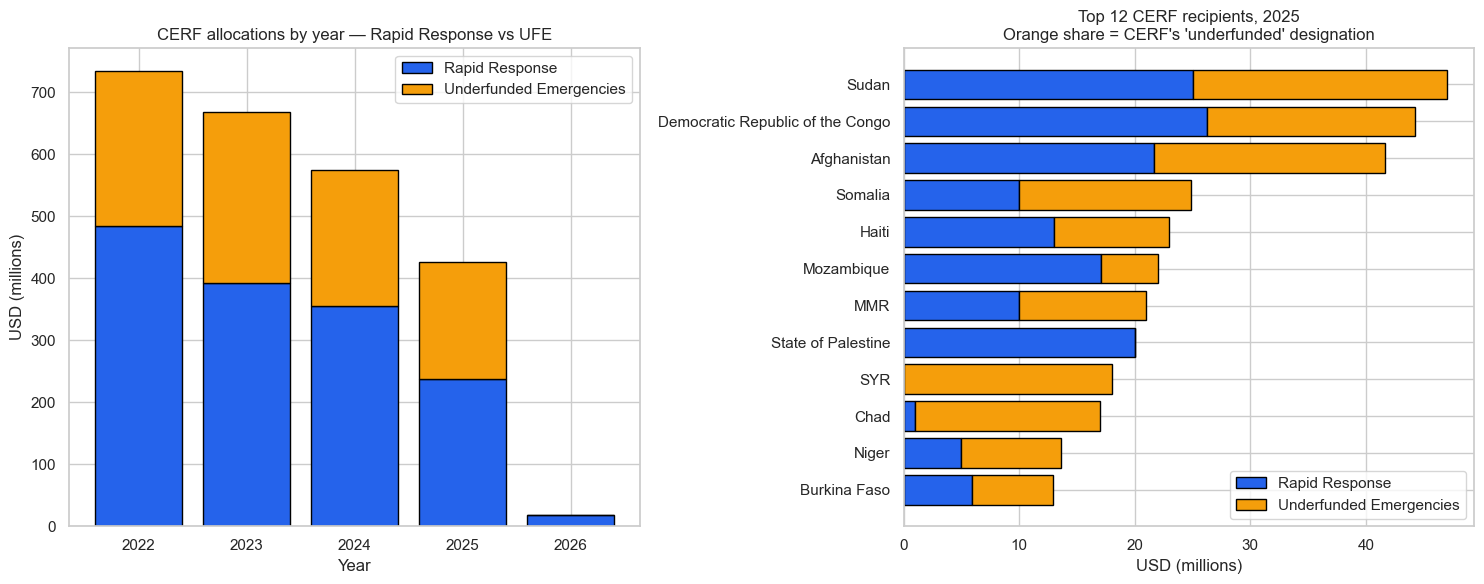


`cerf_country_year` DataFrame ready: 167 country-year rows (2022–2026).


In [23]:
# ============================================================
# WHERE THE CERF MONEY ACTUALLY GOES
# ============================================================
# The FTS file only shows DONOR -> CERF (money flowing into the
# pool). The CERF Allocations dataset shows the onward leg —
# CERF -> implementing agency FOR a specific country. This is
# what answers "where does CERF money go?"
#
# The window split is strategically important:
#   - Rapid Response (RR): sudden-onset emergencies
#   - Underfunded Emergencies (UFE): CERF's OWN formal designation
#     of crises that donors are neglecting. Twice a year CERF runs
#     an underfunded-emergencies analysis and allocates to the
#     countries it determines are most neglected. UFE = CERF
#     explicitly saying "this crisis is forgotten."
#
# That makes CERF's UFE list an external validation signal for
# our own forgotten-crisis ranking.

CERF_PATH = DATA_DIR / "Data_ CERF Donor Contributions and Allocations - allocations.csv"
cerf_raw = pd.read_csv(CERF_PATH)

# ---- 1. Clean + restrict to relevant years -----------------------------
# Standardise column names to match the rest of the notebook.
cerf_raw = cerf_raw.rename(columns={
    "countryCode":          "iso3",
    "totalAmountApproved":  "cerf_usd",
    "windowFullName":       "window",
    "agencyName":           "agency",
    "emergencyTypeName":    "emergency_type",
})
cerf_raw["year"] = pd.to_numeric(cerf_raw["year"], errors="coerce").astype("Int64")
cerf_raw["cerf_usd"] = pd.to_numeric(cerf_raw["cerf_usd"], errors="coerce").fillna(0)

# Keep the recent years that overlap with our other data sources.
CERF_YEARS = [2022, 2023, 2024, 2025, 2026]
cerf_recent = cerf_raw[cerf_raw["year"].isin(CERF_YEARS)].copy()

# ---- 2. Per-country, per-year aggregation ------------------------------
# Pre-pivot window amounts so groupby stays clean.
cerf_recent["rr_usd"]  = np.where(cerf_recent["window"] == "Rapid Response",          cerf_recent["cerf_usd"], 0)
cerf_recent["ufe_usd"] = np.where(cerf_recent["window"] == "Underfunded Emergencies", cerf_recent["cerf_usd"], 0)

cerf_country_year = (
    cerf_recent
    .groupby(["iso3", "year"], as_index=False)
    .agg(
        cerf_total_usd = ("cerf_usd", "sum"),
        cerf_rr_usd    = ("rr_usd", "sum"),
        cerf_ufe_usd   = ("ufe_usd", "sum"),
        n_projects     = ("projectID", "nunique"),
        n_agencies     = ("agency", "nunique"),
    )
)
cerf_country_year["year"] = cerf_country_year["year"].astype(int)
cerf_country_year["received_ufe"] = cerf_country_year["cerf_ufe_usd"] > 0

# Friendly name
cerf_country_year = cerf_country_year.merge(name_map, on="iso3", how="left")
cerf_country_year["country"] = cerf_country_year["country"].fillna(cerf_country_year["iso3"])

# ---- 3. Latest finalised year: who got CERF money? ---------------------
# 2026 is incomplete in this dataset (only ~13 rows early in the year), so
# 2025 is the most recent finalised view. Adjust to taste.
latest = 2025
latest_slice = (
    cerf_country_year
    .query("year == @latest and cerf_total_usd > 0")
    .sort_values("cerf_total_usd", ascending=False)
    .reset_index(drop=True)
)
print(f"CERF allocations — {latest}")
print(f"Countries receiving CERF funds: {len(latest_slice)}")
print(f"Total CERF allocated that year: ${latest_slice['cerf_total_usd'].sum()/1e6:.1f}M")
print(f"  Rapid Response:           ${latest_slice['cerf_rr_usd'].sum()/1e6:.1f}M")
print(f"  Underfunded Emergencies:  ${latest_slice['cerf_ufe_usd'].sum()/1e6:.1f}M")
print(f"Countries designated UFE (CERF's own 'neglected' flag): "
      f"{int(latest_slice['received_ufe'].sum())}")

top15 = latest_slice.head(15).copy()
top15["Total"]  = top15["cerf_total_usd"].apply(lambda x: "$" + format_num(x))
top15["RR"]     = top15["cerf_rr_usd"].apply(lambda x: "$" + format_num(x))
top15["UFE"]    = top15["cerf_ufe_usd"].apply(lambda x: "$" + format_num(x))
top15["UFE?"]   = top15["received_ufe"].map({True: "✓", False: "—"})
top15["# proj"] = top15["n_projects"]
disp = top15[["country", "Total", "RR", "UFE", "UFE?", "# proj"]].rename(
    columns={"country": "Country"}
)
print(f"\nTop 15 CERF recipients in {latest}:")
display(disp.style.hide(axis="index")
        .set_caption(f"CERF allocations by country — {latest}"))

# ---- 4. Multi-year UFE tracker ----------------------------------------
# A country on CERF's UFE list for multiple years in a row is by definition
# a structurally-neglected crisis — this is the single cleanest external
# validator for the "chronic neglect" bonus task.
ufe_years = (
    cerf_country_year[cerf_country_year["received_ufe"]]
    .groupby(["iso3", "country"], as_index=False)
    .agg(ufe_year_list=("year", lambda s: sorted(s.unique().tolist())),
         n_ufe_years  =("year", "nunique"),
         ufe_total_usd=("cerf_ufe_usd", "sum"))
    .sort_values(["n_ufe_years", "ufe_total_usd"], ascending=[False, False])
)
print(f"\nCountries on CERF's Underfunded Emergencies list "
      f"({min(CERF_YEARS)}–{max(CERF_YEARS)}):")
ufe_disp = ufe_years.head(20).copy()
ufe_disp["UFE years"]  = ufe_disp["ufe_year_list"].apply(lambda lst: ", ".join(str(y) for y in lst))
ufe_disp["UFE total"]  = ufe_disp["ufe_total_usd"].apply(lambda x: "$" + format_num(x))
ufe_disp = ufe_disp.rename(columns={"country": "Country", "n_ufe_years": "# yrs"})[
    ["Country", "# yrs", "UFE years", "UFE total"]
]
display(ufe_disp.style.hide(axis="index")
        .set_caption("CERF's chronically-neglected list (multi-year UFE recipients)"))

# ---- 5. Merge CERF back into the bilateral/CBPF channel view ----------
# If `fts_by_channel` exists (from the earlier FTS-channels cell), update
# its CERF column with the real country-attributed numbers. For the latest
# finalised year.
try:
    latest_cerf_amt = (
        cerf_country_year.query("year == @latest")
        .set_index("iso3")["cerf_total_usd"]
    )
    if "fts_by_channel" in globals():
        fts_by_channel_augmented = fts_by_channel.copy()
        # Replace the (currently zero) cerf_usd column with real allocations.
        fts_by_channel_augmented["cerf_usd_real"] = (
            fts_by_channel_augmented["iso3"].map(latest_cerf_amt).fillna(0)
        )
        fts_by_channel_augmented["total_with_cerf"] = (
            fts_by_channel_augmented["bilateral_usd"]
            + fts_by_channel_augmented["cbpf_usd"]
            + fts_by_channel_augmented["cerf_usd_real"]
        )
        fts_by_channel_augmented["pct_pooled_real"] = np.where(
            fts_by_channel_augmented["total_with_cerf"] > 0,
            (fts_by_channel_augmented["cbpf_usd"] + fts_by_channel_augmented["cerf_usd_real"])
            / fts_by_channel_augmented["total_with_cerf"],
            np.nan,
        )
        print(f"\n`fts_by_channel` augmented with real CERF {latest} allocations in "
              f"`fts_by_channel_augmented`.")
except Exception as e:
    print(f"\n(Channel merge skipped: {e})")

# ---- 6. Visualise: CERF allocations by year, RR vs UFE ----------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: annual totals, RR vs UFE stacked
annual = (
    cerf_country_year
    .groupby("year", as_index=False)
    .agg(rr=("cerf_rr_usd", "sum"), ufe=("cerf_ufe_usd", "sum"))
    .sort_values("year")
)
x = annual["year"].astype(str)
axes[0].bar(x, annual["rr"] / 1e6, color="#2563eb", edgecolor="black", label="Rapid Response")
axes[0].bar(x, annual["ufe"] / 1e6, bottom=annual["rr"] / 1e6,
            color="#f59e0b", edgecolor="black", label="Underfunded Emergencies")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("USD (millions)")
axes[0].set_title("CERF allocations by year — Rapid Response vs UFE")
axes[0].legend(loc="upper right")

# Right: top 12 recipients in latest year, with UFE share highlighted
top12 = latest_slice.head(12).sort_values("cerf_total_usd", ascending=True)
axes[1].barh(top12["country"], top12["cerf_rr_usd"] / 1e6,
             color="#2563eb", edgecolor="black", label="Rapid Response")
axes[1].barh(top12["country"], top12["cerf_ufe_usd"] / 1e6,
             left=top12["cerf_rr_usd"] / 1e6,
             color="#f59e0b", edgecolor="black", label="Underfunded Emergencies")
axes[1].set_xlabel("USD (millions)")
axes[1].set_title(f"Top 12 CERF recipients, {latest}\n"
                  "Orange share = CERF's 'underfunded' designation")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

print(f"\n`cerf_country_year` DataFrame ready: {len(cerf_country_year):,} country-year rows "
      f"({CERF_YEARS[0]}–{CERF_YEARS[-1]}).")

Countries in the analysis: 19
  Received CERF UFE in 2025: 13
  Did not:                           6

Median mismatch score, UFE group:     0.566
Median mismatch score, non-UFE group: 0.375
Point-biserial correlation:  r = +0.122   (p = 0.6201)
Mann–Whitney U, one-sided:   U = 45   (p = 0.3147)
  H1: UFE-recipient countries have higher mismatch scores.


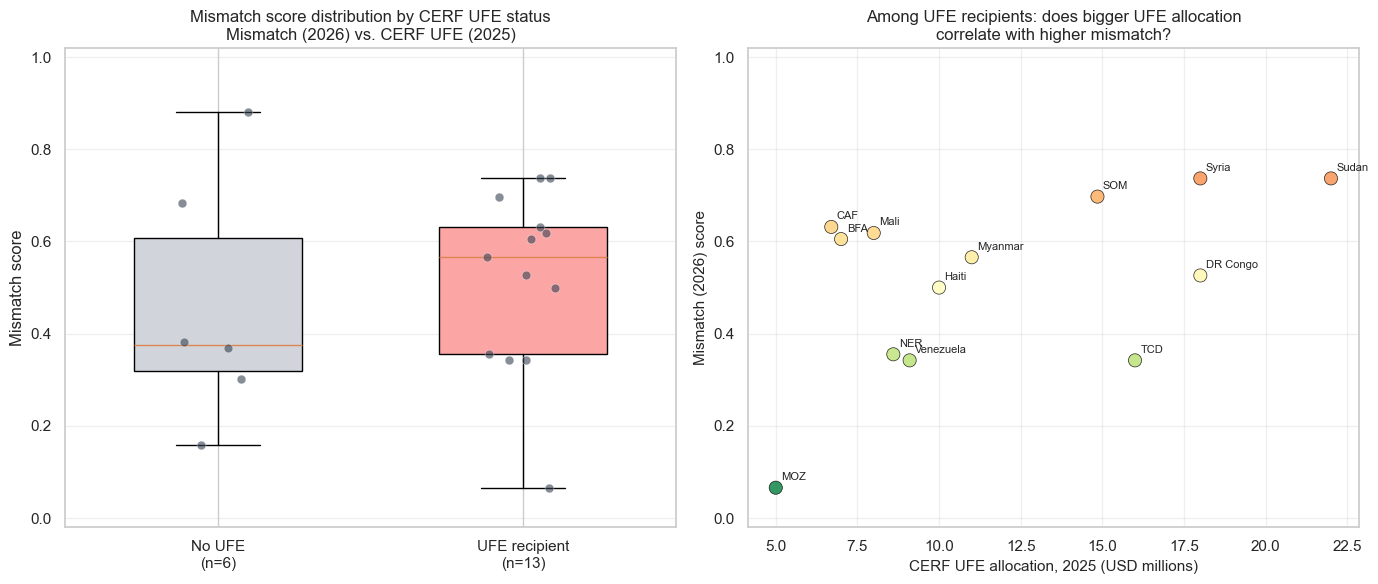


CERF UFE recipients in 2025, sorted by our 2026 mismatch score:
  Country  Severity Coverage  Mismatch UFE (2025)
    Sudan       4.7    11.8%     0.737     $22.0M
    Syria       4.5     7.2%     0.737     $18.0M
      SOM       4.3     4.8%     0.697     $14.8M
      CAF       4.0     3.9%     0.632      $6.7M
     Mali       4.2     4.9%     0.618      $8.0M
      BFA       4.0     4.0%     0.605      $7.0M
  Myanmar       4.6    22.3%     0.566     $11.0M
 DR Congo       4.5    21.7%     0.526     $18.0M
    Haiti       4.4    16.7%     0.500     $10.0M
      NER       3.6     7.4%     0.355      $8.6M
Venezuela       3.8     9.9%     0.342      $9.1M
      TCD       4.0    13.3%     0.342     $16.0M
      MOZ       3.6    32.0%     0.066      $5.0M

Highest-mismatch countries that did NOT receive UFE in 2025:
    Country  Severity Coverage  Mismatch Any CERF (2025)
      Yemen       4.6     4.3%     0.882              $0
South Sudan       4.5     8.4%     0.684          $10.0M
  

In [24]:
# ============================================================
# VALIDATION: does our mismatch score line up with CERF's UFE list?
# ============================================================
# CERF's Underfunded Emergencies window is OCHA's own, formal,
# twice-yearly designation of the crises that donors are neglecting.
# If our mismatch score captures the same signal, UFE-recipient
# countries should cluster at the high end of our mismatch
# distribution. This cell tests that directly.
#
# Date-matching note:
#   - Our mismatch score uses 2026 FTS data (with 2025 INFORM
#     severity as proxy — the notebook already does this).
#   - CERF UFE data is essentially finalised through 2025 (the
#     first 2026 UFE allocation round typically runs mid-year).
#   So we compare our 2026 mismatch to CERF's 2025 UFE designation.
#   This is actually a well-posed question: "does our current-year
#   score pick up the same countries CERF formally flagged last
#   year?" Agreement validates the method; disagreement suggests
#   either emerging crises (we flag them before CERF) or stale
#   UFE designations.

MISMATCH_YEAR = 2026   # year for which we computed the mismatch score
CERF_YEAR     = 2025   # most recent fully-finalised CERF UFE list

# ---- 1. Rebuild the mismatch score for the target year --------------
# We re-derive it here so the cell is self-contained and doesn't depend
# on the scatter plot having cached intermediate columns.
sev = core_enriched[["iso3", "year", "severity_index"]].dropna(
    subset=["severity_index"]
)
mis = (
    hrp_fts.query("year == @MISMATCH_YEAR and req_sum > 0")
    .merge(sev, on=["iso3", "year"], how="left")
    .dropna(subset=["severity_index"])
    .copy()
)
mis["allocated_usd"] = mis["fts_total_reported"]
mis["cov_ratio"]     = mis["allocated_usd"] / mis["req_sum"]
mis["sev_pct"]       = mis["severity_index"].rank(pct=True, method="average")
mis["cov_pct"]       = mis["cov_ratio"].rank(pct=True, method="average")
mis["mismatch"]      = (mis["sev_pct"] + (1 - mis["cov_pct"])) / 2

# ---- 2. Pull CERF UFE status from the allocations-derived table -----
# `cerf_country_year` was built in the earlier CERF cell with columns
# iso3, year, received_ufe (bool), cerf_ufe_usd, cerf_total_usd, ...
cerf_slice = cerf_country_year[cerf_country_year["year"] == CERF_YEAR][
    ["iso3", "received_ufe", "cerf_ufe_usd", "cerf_total_usd"]
].copy()

# ---- 3. Merge: left-join UFE onto our mismatch frame -----------------
# Countries in our mismatch frame that don't appear in the CERF slice
# simply didn't receive any CERF that year — safely coerce to not-UFE.
val = mis.merge(cerf_slice, on="iso3", how="left")
val["received_ufe"]   = val["received_ufe"].fillna(False).astype(bool)
val["cerf_ufe_usd"]   = val["cerf_ufe_usd"].fillna(0)
val["cerf_total_usd"] = val["cerf_total_usd"].fillna(0)

n_total = len(val)
n_ufe   = int(val["received_ufe"].sum())
print(f"Countries in the analysis: {n_total}")
print(f"  Received CERF UFE in {CERF_YEAR}: {n_ufe}")
print(f"  Did not:                           {n_total - n_ufe}")

# ---- 4. Statistical agreement ---------------------------------------
# Point-biserial correlation (Pearson between continuous mismatch and
# binary UFE) + a Mann-Whitney U test comparing the two groups. The
# Mann-Whitney is rank-based and more robust than the t-test given
# the mismatch score's bounded [0, 1] distribution.
from scipy import stats

r_pb, p_pb = stats.pointbiserialr(val["received_ufe"].astype(int),
                                  val["mismatch"])
u_stat, p_u = stats.mannwhitneyu(
    val.loc[val["received_ufe"],  "mismatch"],
    val.loc[~val["received_ufe"], "mismatch"],
    alternative="greater",   # hypothesis: UFE group has higher mismatch
)
median_ufe    = val.loc[val["received_ufe"],  "mismatch"].median()
median_no_ufe = val.loc[~val["received_ufe"], "mismatch"].median()

print(f"\nMedian mismatch score, UFE group:     {median_ufe:.3f}")
print(f"Median mismatch score, non-UFE group: {median_no_ufe:.3f}")
print(f"Point-biserial correlation:  r = {r_pb:+.3f}   (p = {p_pb:.4f})")
print(f"Mann–Whitney U, one-sided:   U = {u_stat:.0f}   (p = {p_u:.4f})")
print("  H1: UFE-recipient countries have higher mismatch scores.")

# ---- 5. Visualise ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left: distribution of mismatch by UFE status ---
# Strip plot on a box plot: compact, honest about small-N groups.
ufe_scores    = val.loc[val["received_ufe"],  "mismatch"].values
no_ufe_scores = val.loc[~val["received_ufe"], "mismatch"].values

box_data = [no_ufe_scores, ufe_scores]
bp = axes[0].boxplot(
    box_data, labels=[f"No UFE\n(n={len(no_ufe_scores)})",
                      f"UFE recipient\n(n={len(ufe_scores)})"],
    widths=0.55, patch_artist=True, showfliers=False,
)
for patch, colour in zip(bp["boxes"], ["#d1d5db", "#fca5a5"]):
    patch.set_facecolor(colour)
    patch.set_edgecolor("black")

# Overlay individual points so N is obvious and outliers are named
rng = np.random.default_rng(0)
for i, (scores, xpos) in enumerate([(no_ufe_scores, 1), (ufe_scores, 2)]):
    jitter = rng.uniform(-0.12, 0.12, len(scores))
    axes[0].scatter(np.full(len(scores), xpos) + jitter, scores,
                    s=40, alpha=0.6, color="#374151",
                    edgecolor="white", linewidth=0.4, zorder=3)

axes[0].set_ylabel("Mismatch score", fontsize=12)
axes[0].set_title(
    f"Mismatch score distribution by CERF UFE status\n"
    f"Mismatch ({MISMATCH_YEAR}) vs. CERF UFE ({CERF_YEAR})",
    fontsize=12,
)
axes[0].set_ylim(-0.02, 1.02)
axes[0].grid(axis="y", alpha=0.3)

# --- Right: mismatch vs UFE dollars (continuous check) ---
# For countries that did receive UFE, does a bigger UFE allocation
# correlate with a higher mismatch score? If CERF is targeting the
# most-neglected crises with the biggest UFE slices, we'd expect yes.
ufe_only = val[val["received_ufe"]].copy()
axes[1].scatter(
    ufe_only["cerf_ufe_usd"] / 1e6,
    ufe_only["mismatch"],
    s=90, c=ufe_only["mismatch"], cmap="RdYlGn_r",
    vmin=0, vmax=1, alpha=0.85,
    edgecolor="black", linewidth=0.5,
)
for _, row in ufe_only.iterrows():
    axes[1].annotate(
        row["country"],
        (row["cerf_ufe_usd"] / 1e6, row["mismatch"]),
        fontsize=8, ha="left", va="bottom",
        xytext=(4, 4), textcoords="offset points",
    )
axes[1].set_xlabel(f"CERF UFE allocation, {CERF_YEAR} (USD millions)", fontsize=11)
axes[1].set_ylabel("Mismatch (2026) score", fontsize=11)
axes[1].set_title("Among UFE recipients: does bigger UFE allocation\ncorrelate with higher mismatch?",
                  fontsize=12)
axes[1].set_ylim(-0.02, 1.02)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---- 6. Named side-by-side check ------------------------------------
# Print UFE recipients ranked by our mismatch score, so a reader can
# eyeball the agreement. A very-high-mismatch country that got a big
# UFE slice is a 'both methods agree' case; a low-mismatch UFE country
# is worth investigating — either CERF is flagging something we miss
# (emerging crisis, sector-level gap) or our mismatch isn't capturing it.
print(f"\nCERF UFE recipients in {CERF_YEAR}, sorted by our {MISMATCH_YEAR} mismatch score:")
show = (
    val[val["received_ufe"]]
    .sort_values("mismatch", ascending=False)
    [["country", "severity_index", "cov_ratio", "mismatch", "cerf_ufe_usd"]]
    .copy()
)
show["severity_index"] = show["severity_index"].round(2)
show["cov_ratio"]      = (show["cov_ratio"] * 100).round(1).astype(str) + "%"
show["mismatch"]       = show["mismatch"].round(3)
show["cerf_ufe_usd"]   = show["cerf_ufe_usd"].apply(lambda x: "$" + format_num(x))
show = show.rename(columns={
    "country": "Country", "severity_index": "Severity",
    "cov_ratio": "Coverage", "mismatch": "Mismatch",
    "cerf_ufe_usd": f"UFE ({CERF_YEAR})",
})
print(show.to_string(index=False))

# And the flipside — high-mismatch countries that did NOT get UFE money.
# These are candidates where our method identifies neglect that CERF hasn't
# formally flagged (yet). Worth investigating.
print(f"\nHighest-mismatch countries that did NOT receive UFE in {CERF_YEAR}:")
miss = (
    val[~val["received_ufe"]]
    .nlargest(7, "mismatch")
    [["country", "severity_index", "cov_ratio", "mismatch", "cerf_total_usd"]]
    .copy()
)
miss["severity_index"] = miss["severity_index"].round(2)
miss["cov_ratio"]      = (miss["cov_ratio"] * 100).round(1).astype(str) + "%"
miss["mismatch"]       = miss["mismatch"].round(3)
miss["cerf_total_usd"] = miss["cerf_total_usd"].apply(lambda x: "$" + format_num(x))
miss = miss.rename(columns={
    "country": "Country", "severity_index": "Severity",
    "cov_ratio": "Coverage", "mismatch": "Mismatch",
    "cerf_total_usd": f"Any CERF ({CERF_YEAR})",
})
print(miss.to_string(index=False))

# 3. Media attention as an explanatory layer

The four types above (A–D) tell us *how* crises are underserved, but not *why*.
One common hypothesis is the **"forgotten crisis" story**: donors fund what
the press covers, so low media attention causes low funding.

We test this by layering GDELT-derived English-language news coverage on top
of the results we already have. Three specific comparisons, each answering a
different question:

1. **Media coverage vs. our mismatch score** — does news attention track the
   severity-vs-resources mismatch we computed in `core_enriched`? Unlike the
   standalone media-vs-`Pct_Funded` correlation, this uses our own mismatch
   construction, so the axes are consistent with the rest of the notebook.
2. **Media coverage by crisis type (A/B/C/D)** — the typology-aware view.
   Type A (invisible in the pipeline) and Type B (documented but unplanned)
   should be systematically lower in media coverage if the invisibility
   story holds. Type C (planned but unfunded) could still be loud in the
   press and yet underfunded, which would point at donor priorities rather
   than visibility.
3. **Media coverage vs. CERF UFE designation** — does the press cluster on
   or away from the crises that OCHA itself formally flags as underfunded?
   This reuses the validation frame from the CERF/UFE cell above.

The data source is the same GDELT media share used in the standalone
`news_analysis.ipynb` — per-country CSVs of `frac = share of English news
articles mentioning the country`, averaged to annual means.


In [25]:
# Load per-country media coverage (GDELT) and build annual means
# --------------------------------------------------------------
# Each CSV in data/media/<ISO3>.csv has daily `frac` = fraction of English
# GDELT articles mentioning that country. We average to annual per-country
# series and join onto core_enriched so we can compare media attention to
# the mismatch, severity and crisis-type fields already on that table.

MEDIA_DIR = DATA_DIR / "media"

frames = []
for path in sorted(MEDIA_DIR.glob("*.csv")):
    iso3 = path.stem.upper()
    df_m = pd.read_csv(path, parse_dates=["date"])
    df_m["date"] = pd.to_datetime(df_m["date"], utc=True, errors="coerce")
    df_m["iso3"] = iso3
    frames.append(df_m)

if not frames:
    raise RuntimeError(
        "No media CSVs found in data/media/. "
        "Run the GDELT prefetch script before executing this section."
    )

media_all = pd.concat(frames, ignore_index=True)
media_all["year"] = media_all["date"].dt.year

media_annual = (
    media_all
    .dropna(subset=["frac"])
    .groupby(["iso3", "year"], as_index=False)["frac"]
    .mean()
    .rename(columns={"frac": "media_frac"})
)
media_annual["media_frac_pct"] = media_annual["media_frac"] * 100

# Log10 for plotting — many countries have very small shares
media_annual["log10_media_frac_pct"] = np.log10(
    media_annual["media_frac_pct"].where(media_annual["media_frac_pct"] > 0)
)

print(
    f"Media coverage: {media_annual['iso3'].nunique()} countries, "
    f"{media_annual['year'].min()}–{media_annual['year'].max()}, "
    f"{len(media_annual):,} country-years"
)

# Attach to the main analysis table
core_media = core_enriched.merge(media_annual, on=["iso3", "year"], how="left")
coverage = core_media["media_frac_pct"].notna().mean()
print(f"Media match rate onto core_enriched: {coverage:.0%}")

core_media[["country", "year", "severity_index",
            "mismatch", "media_frac_pct"]].head(10)


Media coverage: 104 countries, 2021–2026, 600 country-years
Media match rate onto core_enriched: 95%


,country,year,severity_index,mismatch,media_frac_pct
0,Afghanistan,2024,4.4,0.375000,0.554935
1,Burkina Faso,2024,4.2,-0.291667,0.067562
2,CAF,2024,4.0,0.166667,0.033437
3,Cameroon,2024,3.7,-0.291667,0.074944
4,Democratic Republic of the Congo,2024,4.4,0.000000,0.055618
5,Colombia,2024,4.1,0.083333,NaN
6,Ethiopia,2024,4.3,-0.541667,0.209368
7,Guatemala,2024,3.5,0.458333,0.118588
8,Honduras,2024,3.4,0.291667,0.075813
9,Haiti,2024,4.0,0.333333,0.258787


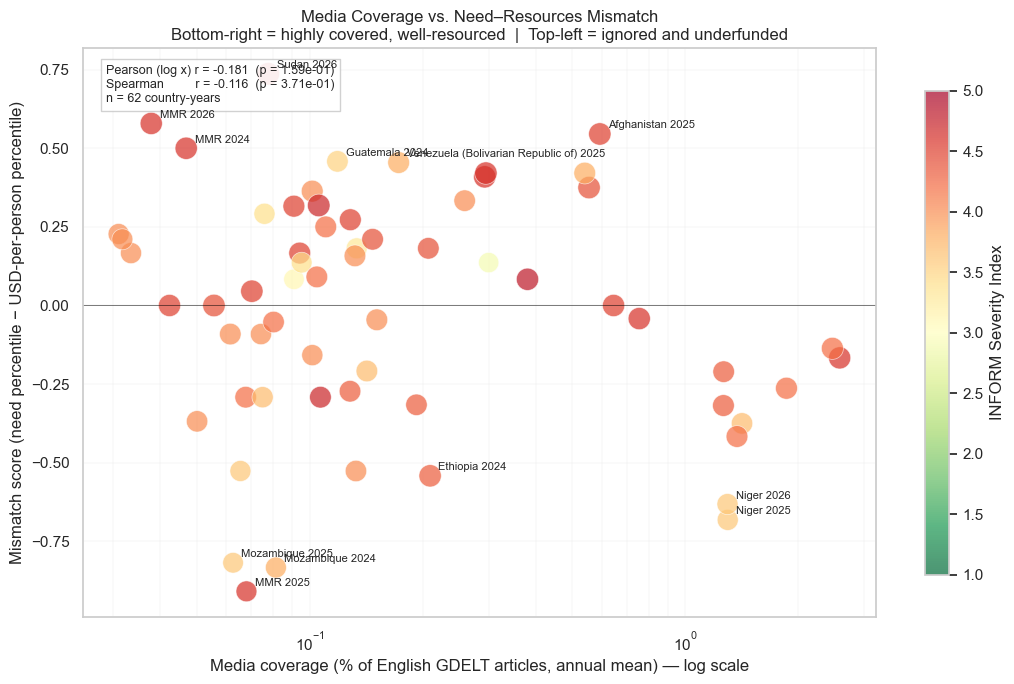

In [26]:
# Chart 1 — Media coverage vs. our mismatch score
# -------------------------------------------------
# Mismatch (from cell 18) = need_rate_pct − usd_per_in_need_pct, within-year.
# Positive = high need + low requested resources. If the "forgotten crisis"
# story holds, we expect a negative relationship: less media attention →
# higher mismatch.

from scipy import stats

plot_df = (
    core_media
    .dropna(subset=["mismatch", "media_frac_pct", "severity_index"])
    .query("media_frac_pct > 0")
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 7))

# Size by people in need (so big caseloads read visually)
sizes = (
    np.log1p(plot_df["in_need"]) / np.log1p(plot_df["in_need"]).max() * 240 + 25
)

sc = ax.scatter(
    plot_df["media_frac_pct"],
    plot_df["mismatch"],
    c=plot_df["severity_index"],
    s=sizes,
    cmap="RdYlGn_r",
    vmin=1, vmax=5,
    alpha=0.7,
    edgecolors="white",
    linewidth=0.5,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("INFORM Severity Index")

ax.set_xscale("log")
ax.axhline(0, color="black", linewidth=0.6, alpha=0.6)
ax.set_xlabel("Media coverage (% of English GDELT articles, annual mean) — log scale")
ax.set_ylabel("Mismatch score (need percentile − USD-per-person percentile)")
ax.set_title("Media Coverage vs. Need–Resources Mismatch\n"
             "Bottom-right = highly covered, well-resourced  |  "
             "Top-left = ignored and underfunded")

# Correlation on log(media)
r_p, p_p = stats.pearsonr(
    np.log10(plot_df["media_frac_pct"]), plot_df["mismatch"]
)
r_s, p_s = stats.spearmanr(plot_df["media_frac_pct"], plot_df["mismatch"])
ax.text(
    0.03, 0.97,
    f"Pearson (log x) r = {r_p:+.3f}  (p = {p_p:.2e})\n"
    f"Spearman         r = {r_s:+.3f}  (p = {p_s:.2e})\n"
    f"n = {len(plot_df)} country-years",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.9, edgecolor="#ccc"),
)

# Label the worst-served, least-covered corner (top-left) and its opposite
top_left = plot_df.nlargest(6, "mismatch")
bot_right = plot_df.nsmallest(6, "mismatch")
for _, row in pd.concat([top_left, bot_right]).drop_duplicates(
        subset=["iso3", "year"]).iterrows():
    ax.annotate(
        f"{row['country']} {int(row['year'])}",
        (row["media_frac_pct"], row["mismatch"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

ax.grid(True, which="both", linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()


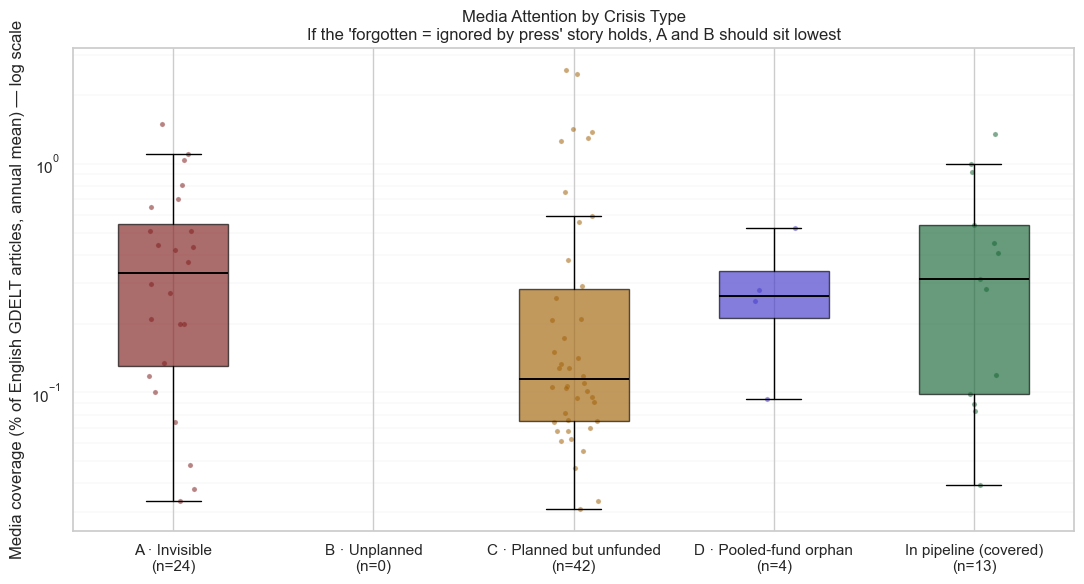


Media coverage by crisis type:
                          count  median   mean
type                                          
A · Invisible              24.0   0.335  0.426
B · Unplanned               NaN     NaN    NaN
C · Planned but unfunded   42.0   0.114  0.387
D · Pooled-fund orphan      4.0   0.265  0.287
In pipeline (covered)      13.0   0.314  0.438


In [27]:
# Chart 2 — Media coverage across the A/B/C/D crisis typology
# ----------------------------------------------------------------
# We re-derive pipeline-stage membership from the same rules used in the
# Type A cell (cell 20), then layer media coverage on top. The reason we
# rebuild instead of caching earlier: the Type A cell scopes to
# `ANALYSIS_YEARS = [2024, 2025]` while other typology cells use 2026.
# Here we want all three planning years on the same axes.

# ---- Presence flags ----------------------------------------------------
hno_has = (
    hno_clean.query("Cluster == 'ALL' and Category == ''")
    .rename(columns={"Country ISO3": "iso3", "In Need": "in_need_check"})
    .assign(in_need_check=lambda d: pd.to_numeric(d["in_need_check"], errors="coerce"))
    .dropna(subset=["in_need_check"])
    .query("in_need_check > 0")
    [["iso3", "year"]].drop_duplicates()
    .assign(has_hno=True)
)

hrp_has = (
    hrp_agg.query("req_sum > 0")[["iso3", "year"]]
    .drop_duplicates()
    .assign(has_hrp=True)
)

# ---- Build the typology frame (severe country-years only) --------------
SEV_FLOOR = 3.0   # same threshold as cell 20

typ = (
    inform_master
    .dropna(subset=["severity_index", "iso3", "year"])
    .assign(year=lambda d: d["year"].astype(int))
    .query("severity_index >= @SEV_FLOOR and year in @YEARS")
    .drop_duplicates(subset=["iso3", "year"])
    [["iso3", "year", "severity_index"]]
    .merge(hno_has, on=["iso3", "year"], how="left")
    .merge(hrp_has, on=["iso3", "year"], how="left")
)
typ["has_hno"] = typ["has_hno"].fillna(False)
typ["has_hrp"] = typ["has_hrp"].fillna(False)

# Attach HRP coverage ratio (for the C vs. B/D split)
typ = typ.merge(
    hrp_fts[["iso3", "year", "coverage_ratio"]],
    on=["iso3", "year"], how="left",
)

# Attach CBPF/CERF receipt (for Type D)
pool = cerf_country_year[["iso3", "year", "cerf_total_usd"]].copy()
typ = typ.merge(pool, on=["iso3", "year"], how="left")
typ["cerf_total_usd"] = typ["cerf_total_usd"].fillna(0)

def classify(row):
    # Type A: severe, no HNO, no HRP — invisible in the pipeline
    if not row["has_hno"] and not row["has_hrp"]:
        return "A · Invisible"
    # Type B: severe, HNO exists, no HRP — documented but unplanned
    if row["has_hno"] and not row["has_hrp"]:
        return "B · Unplanned"
    # Has HRP → sort into C vs D by coverage and pooled-fund receipt
    cov = row["coverage_ratio"] if pd.notna(row["coverage_ratio"]) else np.nan
    cerf = row["cerf_total_usd"] or 0
    # Type C: HRP exists but poorly funded (coverage < 0.5)
    if pd.notna(cov) and cov < 0.5:
        return "C · Planned but unfunded"
    # Type D: HRP reasonably funded, but CERF didn't touch it
    if cerf == 0:
        return "D · Pooled-fund orphan"
    return "In pipeline (covered)"

typ["type"] = typ.apply(classify, axis=1)

# Attach media
typ_media = typ.merge(media_annual[["iso3", "year", "media_frac_pct"]],
                      on=["iso3", "year"], how="left")

# ---- Plot --------------------------------------------------------------
order = ["A · Invisible", "B · Unplanned", "C · Planned but unfunded",
         "D · Pooled-fund orphan", "In pipeline (covered)"]
palette = {
    "A · Invisible":              "#7f1d1d",
    "B · Unplanned":              "#b45309",
    "C · Planned but unfunded":   "#a16207",
    "D · Pooled-fund orphan":     "#4338ca",
    "In pipeline (covered)":      "#166534",
}

valid = typ_media.dropna(subset=["media_frac_pct"]).query("media_frac_pct > 0").copy()

fig, ax = plt.subplots(figsize=(11, 6))
data = [valid.loc[valid["type"] == t, "media_frac_pct"].values for t in order]
labels = [f"{t}\n(n={len(d)})" for t, d in zip(order, data)]
bp = ax.boxplot(
    data, labels=labels, vert=True, patch_artist=True, showfliers=False, widths=0.55,
)
for patch, t in zip(bp["boxes"], order):
    patch.set_facecolor(palette[t])
    patch.set_alpha(0.65)
    patch.set_edgecolor("black")
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.4)

# Overlay individual country-years as jittered strip
rng = np.random.default_rng(0)
for i, d in enumerate(data, start=1):
    if len(d) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(i + jitter, d, s=14, alpha=0.55,
               color=palette[order[i-1]], edgecolors="white", linewidth=0.3)

ax.set_yscale("log")
ax.set_ylabel("Media coverage (% of English GDELT articles, annual mean) — log scale")
ax.set_title("Media Attention by Crisis Type\n"
             "If the 'forgotten = ignored by press' story holds, A and B should sit lowest")
ax.grid(True, axis="y", which="both", linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()

# Median table for the interpretation
median_tbl = (
    valid.groupby("type")["media_frac_pct"]
    .agg(["count", "median", "mean"])
    .reindex(order).round(3)
)
print("\nMedia coverage by crisis type:")
print(median_tbl.to_string())


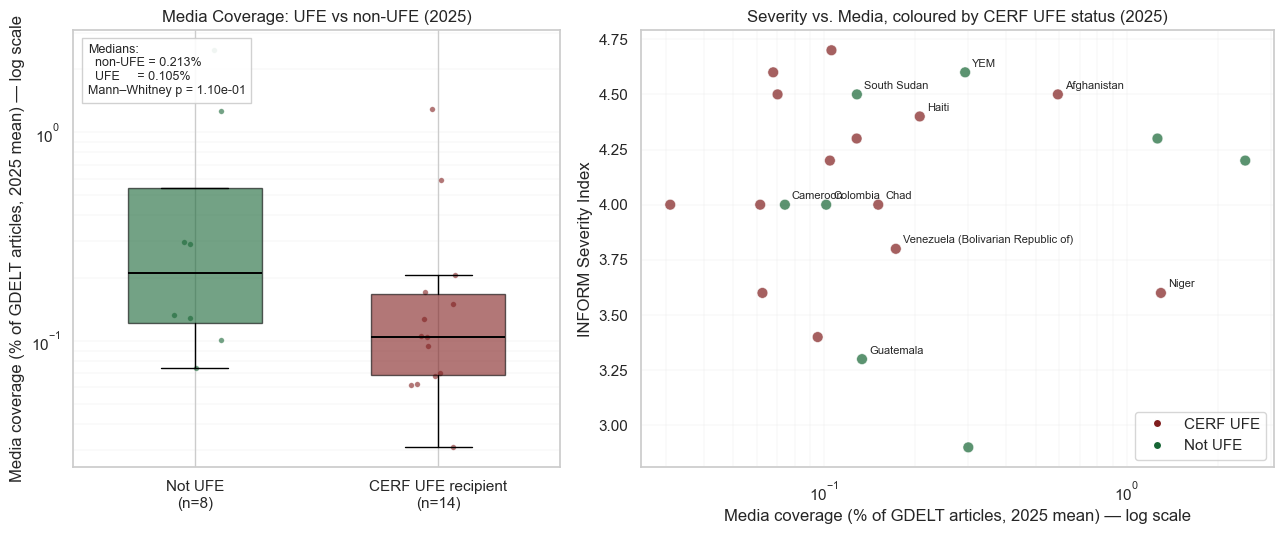

In [28]:
# Chart 3 — Media coverage vs. CERF's Underfunded Emergencies designation
# -------------------------------------------------------------------------
# The earlier cell validated our mismatch score against CERF's UFE list.
# Here we ask the parallel question of the media: do the crises CERF itself
# flags as underfunded receive less press attention than non-UFE crises?
# If media attention drives funding, UFE-designated crises should be
# markedly quieter in the news.

UFE_YEAR = 2025   # same year used in the validation cell above

# Attach UFE flag to our media-joined frame, restricted to that year
ufe_flag = (
    cerf_country_year[cerf_country_year["year"] == UFE_YEAR]
    [["iso3", "received_ufe"]]
)
media_ufe = (
    core_media[core_media["year"] == UFE_YEAR]
    [["iso3", "country", "year", "severity_index",
      "mismatch", "media_frac_pct"]]
    .merge(ufe_flag, on="iso3", how="left")
)
media_ufe["received_ufe"] = media_ufe["received_ufe"].fillna(False).astype(bool)

# Only countries that are actually in our analysis universe, with media data
media_ufe = media_ufe.dropna(subset=["media_frac_pct"]).query("media_frac_pct > 0")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          gridspec_kw={"width_ratios": [1, 1.3]})

# ---- Left: distribution of media coverage, UFE vs non-UFE ----
ax0 = axes[0]
groups = [
    ("Not UFE", media_ufe.loc[~media_ufe["received_ufe"], "media_frac_pct"]),
    ("CERF UFE recipient", media_ufe.loc[media_ufe["received_ufe"], "media_frac_pct"]),
]
positions = [1, 2]
bp = ax0.boxplot(
    [g[1].values for g in groups],
    labels=[f"{name}\n(n={len(g)})" for name, g in groups],
    positions=positions, patch_artist=True, widths=0.55, showfliers=False,
)
for patch, colour in zip(bp["boxes"], ["#166534", "#7f1d1d"]):
    patch.set_facecolor(colour); patch.set_alpha(0.6); patch.set_edgecolor("black")
for m in bp["medians"]:
    m.set_color("black"); m.set_linewidth(1.4)

rng = np.random.default_rng(1)
for i, (_, vals) in enumerate(groups, start=1):
    if len(vals) == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax0.scatter(i + jitter, vals, s=16, alpha=0.6,
                color=["#166534", "#7f1d1d"][i-1],
                edgecolors="white", linewidth=0.3)

ax0.set_yscale("log")
ax0.set_ylabel("Media coverage (% of GDELT articles, 2025 mean) — log scale")
ax0.set_title(f"Media Coverage: UFE vs non-UFE ({UFE_YEAR})")
ax0.grid(True, axis="y", which="both", linewidth=0.3, alpha=0.4)

# Mann–Whitney U since the distributions are heavily skewed
nonufe_vals = groups[0][1].values
ufe_vals    = groups[1][1].values
if len(ufe_vals) > 0 and len(nonufe_vals) > 0:
    u, p = stats.mannwhitneyu(ufe_vals, nonufe_vals, alternative="two-sided")
    ax0.text(
        0.03, 0.97,
        f"Medians:\n  non-UFE = {np.median(nonufe_vals):.3f}%\n"
        f"  UFE     = {np.median(ufe_vals):.3f}%\n"
        f"Mann–Whitney p = {p:.2e}",
        transform=ax0.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.9, edgecolor="#ccc"),
    )

# ---- Right: the same info in the severity-vs-media plane ----
ax1 = axes[1]
colors = media_ufe["received_ufe"].map({True: "#7f1d1d", False: "#166534"})
ax1.scatter(
    media_ufe["media_frac_pct"], media_ufe["severity_index"],
    c=colors, s=60, alpha=0.7, edgecolors="white", linewidth=0.5,
)
ax1.set_xscale("log")
ax1.set_xlabel("Media coverage (% of GDELT articles, 2025 mean) — log scale")
ax1.set_ylabel("INFORM Severity Index")
ax1.set_title(f"Severity vs. Media, coloured by CERF UFE status ({UFE_YEAR})")

# Label the loudest UFE cases and quietest non-UFE cases
loud_ufe = media_ufe[media_ufe["received_ufe"]].nlargest(5, "media_frac_pct")
quiet_non = (media_ufe[~media_ufe["received_ufe"]]
             .query("severity_index >= 3")
             .nsmallest(5, "media_frac_pct"))
for _, row in pd.concat([loud_ufe, quiet_non]).drop_duplicates(subset=["iso3"]).iterrows():
    ax1.annotate(
        row["country"],
        (row["media_frac_pct"], row["severity_index"]),
        textcoords="offset points", xytext=(5, 4), fontsize=8,
    )

from matplotlib.lines import Line2D
ax1.legend(handles=[
    Line2D([0], [0], marker="o", linestyle="", color="#7f1d1d",
           markeredgecolor="white", label="CERF UFE"),
    Line2D([0], [0], marker="o", linestyle="", color="#166534",
           markeredgecolor="white", label="Not UFE"),
], loc="lower right")
ax1.grid(True, which="both", linewidth=0.3, alpha=0.4)

plt.tight_layout()
plt.show()


### Reading the three charts together

The charts above are designed to pull apart *three different hypotheses* for
why a crisis ends up underserved:

| Observation pattern | Most consistent with |
|---|---|
| Chart 1 shows a clear negative slope (low media → high mismatch) | The "forgotten crisis" story: attention drives allocation |
| Chart 2 shows Type A and B sit far below C, D and covered | Invisibility and pipeline absence, not donor discretion, is the main driver — these countries are missing from the press *and* missing from the planning documents |
| Chart 3 shows UFE recipients with comparable media coverage to non-UFE | Media attention is not what's missing — CERF is compensating for a donor-preference gap, not an awareness gap |
| UFE recipients have systematically lower media coverage | CERF is acting as the designated-driver of last resort for the genuinely quiet crises |

One pattern worth watching specifically: country-years that appear in the
**top-left of Chart 1** (high mismatch, low media) are the strongest candidates
for the classical forgotten-crisis narrative. Country-years in the **top-right**
(high mismatch *despite* high media attention) are the inverse — they suggest
that visibility alone isn't securing resources, which moves the explanation
toward donor priorities, geopolitics, or access constraints rather than
awareness.

Limitations to keep in mind when interpreting these results:

- GDELT indexes English-language online news. Crises covered primarily in
  regional or non-English press (large parts of the Sahel, the Horn, Latin
  America) will look quieter than they actually are.
- `media_frac_pct` measures *share of global articles*, which is a
  relative-attention metric. A country can have rising absolute coverage and
  still a falling share in a year with a big dominating story (e.g. a major
  conflict elsewhere).
- The mismatch score uses *requested* resources (HRP `revisedRequirements`),
  not disbursed funds, so Chart 1 answers "does media track the ask-vs-need
  gap?" — the disbursed-funds version is closer to what Chart 3's UFE axis
  is capturing.
